
# Navier–Stokes PINNsFormer：4-Loss ConFIG × 3 Seeds

本 notebook 延续已经完成的 2-loss 多 seed 实验，但**只新增训练 ConFIG-4**：

$$
L_1=L_{u,\mathrm{data}},\qquad
L_2=L_{v,\mathrm{data}},\qquad
L_3=L_{f_u},\qquad
L_4=L_{f_v}.
$$

与已有 ConFIG-2 的区别只是梯度协调粒度：

$$
\mathrm{ConFIG\text{-}2}
=
\mathrm{ConFIG}
\left(
g_{u}+g_{v},
g_{f_u}+g_{f_v}
\right),
$$

$$
\mathrm{ConFIG\text{-}4}
=
\mathrm{ConFIG}
\left(
g_{u},
g_{v},
g_{f_u},
g_{f_v}
\right).
$$

其中 $g_i=\nabla_\theta L_i$。

## 为什么不重跑 Adam baseline

已有 Adam Simple-Sum 实际优化的总损失就是：

$$
L_{\mathrm{total}}
=
L_{u,\mathrm{data}}
+
L_{v,\mathrm{data}}
+
L_{f_u}
+
L_{f_v}.
$$

因此其参数更新与所谓“4-loss sum baseline”完全相同，可直接复用已有 seed=0,1,2 结果。本 notebook 默认从现有 2-loss 多 seed 输出中读取 Adam 和 ConFIG-2 汇总结果，仅重新训练：

```text
seed 0 -> ConFIG-4
seed 1 -> ConFIG-4
seed 2 -> ConFIG-4
```

## 本次新增诊断

4-loss 除了保留最终场误差、physics loss、threshold、wall time、VRAM 外，还会记录：

- 四个原始 loss；
- 四个参数梯度范数；
- 6 个 pairwise cosine；
- pairwise conflict rate；
- worst pairwise cosine；
- 每个 loss 的 conflict degree；
- ConFIG 最终公共更新方向与四个原始梯度的 cosine；
- `min_i cos(g_config, g_i)`；
- 每 10 step 的 $4\times4$ cosine heatmap 数据；
- 训练曲线、梯度曲线、pairwise conflict 曲线、post-ConFIG alignment 曲线；
- 每个 seed 的 `u/v/p` Absolute Error 与 mean-aligned pressure Absolute Error；
- 3-seed mean ± std；
- Adam vs ConFIG-2 vs ConFIG-4 的可比指标表。

> 注意：2-loss 的单个 data–physics cosine 与 4-loss 的 pairwise cosine/conflict rate 不是同一统计量，不能把数值机械地横向等价比较。


In [1]:

from pathlib import Path
import os
import sys
import time
import json
import csv
import gc
import random

import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

print("Python executable:", sys.executable)
print("Python version   :", sys.version.split()[0])
print("PyTorch          :", torch.__version__)
print("CUDA runtime     :", torch.version.cuda)
print("CUDA available   :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU              :", torch.cuda.get_device_name(0))


Python executable: /home/simplexity/anaconda3/envs/config_pinn/bin/python
Python version   : 3.10.21
PyTorch          : 2.5.1+cu121
CUDA runtime     : 12.1
CUDA available   : True
GPU              : NVIDIA GeForce GTX 1080 Ti


## 1. 路径与实验配置

In [2]:

# ===== 路径 =====
PINNSFORMER_ROOT = Path(
    os.environ.get("PINNSFORMER_ROOT", "/home/simplexity/cyt/pinnsformer-main")
)

EXPERIMENT_ROOT = Path(
    os.environ.get(
        "PINNSFORMER_CONFIG_ROOT",
        str(PINNSFORMER_ROOT / "pinnsformer-config"),
    )
)

CONFIG_ROOT = Path(
    os.environ.get("CONFIG_ROOT", "/home/simplexity/cyt/ConFIG-main")
)

DATA_PATH = (
    PINNSFORMER_ROOT
    / "demo"
    / "navier_stokes"
    / "cylinder_nektar_wake.mat"
)

# 已有 2-loss 多 seed 输出。
TWOLOSS_ROOT = EXPERIMENT_ROOT / "outputs" / "navier_stokes_multiseed"
TWOLOSS_AGGREGATE = TWOLOSS_ROOT / "aggregate"

# 本次 4-loss 输出。
FOURLOSS_ROOT = EXPERIMENT_ROOT / "outputs" / "navier_stokes_4loss_multiseed"
FOURLOSS_ROOT.mkdir(parents=True, exist_ok=True)

# ===== 运行配置 =====
RUN_SEEDS = [0, 1, 2]
FORCE_RERUN = False

DEVICE = "cuda:0"
N_TRAIN = 800
NUM_STEP = 5
TIME_STEP = 1e-2
EPOCHS = 1000
LR = 1e-4
DIAG_INTERVAL = 10
SNAPSHOT = 100

# 原 Navier-Stokes demo 评估场为 5000 个空间点。
GRID_SHAPE = (50, 100)
EXTENT = [-3, 8, -2, 2]

PHYSICS_THRESHOLDS = [1e-2, 5e-3, 2e-3, 1e-3, 5e-4]

# 训练时每一步本来就需要 4 个 task gradients 做 ConFIG，
# 因此 pairwise/post-ConFIG diagnostics 不增加 task-gradient extraction 次数。
LOSS_KEYS = ["u_data", "v_data", "f_u", "f_v"]
LOSS_LABELS = ["u_data", "v_data", "f_u", "f_v"]

print("PINNSFORMER_ROOT:", PINNSFORMER_ROOT)
print("EXPERIMENT_ROOT :", EXPERIMENT_ROOT)
print("CONFIG_ROOT     :", CONFIG_ROOT)
print("DATA_PATH       :", DATA_PATH)
print("TWOLOSS_ROOT    :", TWOLOSS_ROOT)
print("FOURLOSS_ROOT   :", FOURLOSS_ROOT)
print("RUN_SEEDS       :", RUN_SEEDS)
print("FORCE_RERUN     :", FORCE_RERUN)


PINNSFORMER_ROOT: /home/simplexity/cyt/pinnsformer-main
EXPERIMENT_ROOT : /home/simplexity/cyt/pinnsformer-main/pinnsformer-config
CONFIG_ROOT     : /home/simplexity/cyt/ConFIG-main
DATA_PATH       : /home/simplexity/cyt/pinnsformer-main/demo/navier_stokes/cylinder_nektar_wake.mat
TWOLOSS_ROOT    : /home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/navier_stokes_multiseed
FOURLOSS_ROOT   : /home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/navier_stokes_4loss_multiseed
RUN_SEEDS       : [0, 1, 2]
FORCE_RERUN     : False


In [ ]:
if MODEL_PREDICTION is not None:
    # 模型恢复的 u 场
    plot_2d_field(
        MODEL_PREDICTION["u"],
        f"PINNsFormer reconstructed u field | t={t_snap:.4g}",
        "u_pred",
    )

    # 模型恢复的 v 场
    plot_2d_field(
        MODEL_PREDICTION["v"],
        f"PINNsFormer reconstructed v field | t={t_snap:.4g}",
        "v_pred",
    )

    # 模型恢复的 pressure 场
    plot_2d_field(
        MODEL_PREDICTION["p"],
        f"PINNsFormer reconstructed pressure field | t={t_snap:.4g}",
        "p_pred",
    )

    # 恢复的速度模长
    speed_pred = np.sqrt(
        MODEL_PREDICTION["u"]**2
        + MODEL_PREDICTION["v"]**2
    )

    plot_2d_field(
        speed_pred,
        f"PINNsFormer reconstructed velocity magnitude | t={t_snap:.4g}",
        "|velocity| pred",
    )

## 2. 导入当前公共实现

In [3]:

assert DATA_PATH.exists(), f"Missing data: {DATA_PATH}"
assert CONFIG_ROOT.exists(), f"Missing ConFIG repo: {CONFIG_ROOT}"
assert (EXPERIMENT_ROOT / "navier_stokes_common.py").exists(), (
    f"Missing: {EXPERIMENT_ROOT / 'navier_stokes_common.py'}"
)
assert (EXPERIMENT_ROOT / "gradient_diagnostics.py").exists(), (
    f"Missing: {EXPERIMENT_ROOT / 'gradient_diagnostics.py'}"
)

sys.path.insert(0, str(EXPERIMENT_ROOT))
sys.path.insert(0, str(CONFIG_ROOT))

from conflictfree.grad_operator import ConFIGOperator
from conflictfree.utils import apply_gradient_vector_para_based

from gradient_diagnostics import gradient_vector
from navier_stokes_common import (
    PINNsformer,
    init_weights,
    get_n_params,
    load_training_data,
    compute_ns_losses,
    evaluation_tensors,
)

import conflictfree
print("conflictfree:", conflictfree.__file__)


conflictfree: /home/simplexity/cyt/ConFIG-main/conflictfree/__init__.py


## 3. 通用工具

In [4]:

def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


def ensure_dir(path):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path


def write_dict_rows_csv(path, rows, fieldnames=None):
    path = Path(path)
    rows = list(rows)
    if not rows:
        return
    if fieldnames is None:
        fieldnames = list(rows[0].keys())
    with path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def read_dict_rows_csv(path):
    with Path(path).open("r", newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


def save_history(history, path):
    path = Path(path)
    keys = list(history[0].keys())
    np.savez(
        path,
        **{
            k: np.asarray([row[k] for row in history])
            for k in keys
        },
    )


def load_history(path):
    path = Path(path)
    obj = np.load(path, allow_pickle=True)
    if isinstance(obj, np.lib.npyio.NpzFile):
        out = {k: np.asarray(obj[k]) for k in obj.files}
        obj.close()
        return out
    if isinstance(obj, np.ndarray) and obj.shape == ():
        maybe = obj.item()
        if isinstance(maybe, dict):
            return {k: np.asarray(v) for k, v in maybe.items()}
    raise ValueError(f"Unsupported history file: {path}")


def print_table(rows, columns=None, float_digits=6):
    rows = list(rows)
    if not rows:
        print("(empty)")
        return
    if columns is None:
        columns = list(rows[0].keys())

    def fmt(v):
        if v is None or v == "":
            return ""
        if isinstance(v, (float, np.floating)):
            if np.isnan(v):
                return "nan"
            return f"{float(v):.{float_digits}g}"
        return str(v)

    formatted = [{c: fmt(row.get(c, "")) for c in columns} for row in rows]
    widths = {
        c: max(len(c), max(len(row[c]) for row in formatted))
        for c in columns
    }

    header = " | ".join(c.ljust(widths[c]) for c in columns)
    sep = "-+-".join("-" * widths[c] for c in columns)
    print(header)
    print(sep)
    for row in formatted:
        print(" | ".join(row[c].ljust(widths[c]) for c in columns))


def safe_mean(x):
    x = np.asarray(x, dtype=float)
    return float(np.nanmean(x))


def safe_std(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) <= 1:
        return float("nan")
    return float(np.std(x, ddof=1))


def relative_l2(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    assert y_true.shape == y_pred.shape, (y_true.shape, y_pred.shape)
    return float(
        np.linalg.norm(y_true - y_pred, 2)
        / np.linalg.norm(y_true, 2)
    )


def mae(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return float(np.mean(np.abs(y_true - y_pred)))


def max_abs_error(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return float(np.max(np.abs(y_true - y_pred)))


def align_pressure_mean(p_true, p_pred):
    p_true = np.asarray(p_true).reshape(-1)
    p_pred = np.asarray(p_pred).reshape(-1)
    return p_pred - np.mean(p_pred) + np.mean(p_true)


def first_step_below(history, key, threshold):
    values = np.asarray(history[key], dtype=float)
    steps = np.asarray(history["step"], dtype=int)
    idx = np.where(values < threshold)[0]
    return int(steps[idx[0]]) if len(idx) else np.nan


def cosine_np(a, b, eps=1e-12):
    a = np.asarray(a, dtype=float).reshape(-1)
    b = np.asarray(b, dtype=float).reshape(-1)
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom <= eps:
        return np.nan
    return float(np.dot(a, b) / denom)


## 4. 4-loss 梯度诊断工具

In [5]:

PAIR_NAMES = [
    ("u_data", "v_data"),
    ("u_data", "f_u"),
    ("u_data", "f_v"),
    ("v_data", "f_u"),
    ("v_data", "f_v"),
    ("f_u", "f_v"),
]


def cosine_torch(a, b, eps=1e-12):
    denom = a.norm() * b.norm()
    if float(denom.detach()) <= eps:
        return float("nan")
    return float(
        torch.dot(a, b).detach() / denom.detach()
    )


def pairwise_diagnostics(grads):
    # grads: dict[label] -> flattened parameter gradient
    pair_cos = {}
    for a, b in PAIR_NAMES:
        pair_cos[f"cos_{a}__{b}"] = cosine_torch(grads[a], grads[b])

    finite_pairs = np.asarray(
        [v for v in pair_cos.values() if np.isfinite(v)],
        dtype=float,
    )

    if len(finite_pairs):
        mean_pairwise_cosine = float(np.mean(finite_pairs))
        min_pairwise_cosine = float(np.min(finite_pairs))
        pairwise_conflict_rate = float(np.mean(finite_pairs < 0))
        negative = finite_pairs[finite_pairs < 0]
        mean_negative_cosine = (
            float(np.mean(negative)) if len(negative) else 0.0
        )
    else:
        mean_pairwise_cosine = np.nan
        min_pairwise_cosine = np.nan
        pairwise_conflict_rate = np.nan
        mean_negative_cosine = np.nan

    conflict_degree = {}
    for label in LOSS_LABELS:
        vals = []
        for other in LOSS_LABELS:
            if label == other:
                continue
            a, b = sorted(
                [label, other],
                key=lambda x: LOSS_LABELS.index(x),
            )
            key = f"cos_{a}__{b}"
            if key in pair_cos and np.isfinite(pair_cos[key]):
                vals.append(pair_cos[key])
        conflict_degree[f"conflict_degree_{label}"] = (
            float(np.mean(np.asarray(vals) < 0)) if vals else np.nan
        )

    return {
        **pair_cos,
        "mean_pairwise_cosine": mean_pairwise_cosine,
        "min_pairwise_cosine": min_pairwise_cosine,
        "pairwise_conflict_rate": pairwise_conflict_rate,
        "mean_negative_cosine": mean_negative_cosine,
        **conflict_degree,
    }


def config_alignment_diagnostics(g_config, grads):
    out = {}
    vals = []
    for label in LOSS_LABELS:
        c = cosine_torch(g_config, grads[label])
        out[f"cos_config__{label}"] = c
        if np.isfinite(c):
            vals.append(c)

    out["min_config_alignment"] = (
        float(np.min(vals)) if vals else np.nan
    )
    out["mean_config_alignment"] = (
        float(np.mean(vals)) if vals else np.nan
    )
    out["config_nonpositive_alignment_rate"] = (
        float(np.mean(np.asarray(vals) <= 0))
        if vals else np.nan
    )
    return out


def cosine_matrix_from_row(row):
    matrix = np.eye(4, dtype=float)
    index = {label: i for i, label in enumerate(LOSS_LABELS)}
    for a, b in PAIR_NAMES:
        key = f"cos_{a}__{b}"
        c = float(row[key])
        i, j = index[a], index[b]
        matrix[i, j] = c
        matrix[j, i] = c
    return matrix


## 5. 模型与统一 evaluation

In [6]:

def make_model(device):
    model = PINNsformer(
        d_out=2,
        d_hidden=512,
        d_model=32,
        N=1,
        heads=2,
    ).to(device)
    model.apply(init_weights)
    return model


def evaluation_truth(reference, device):
    ev, truth_raw = evaluation_tensors(
        reference,
        device,
        snap=SNAPSHOT,
        num_step=NUM_STEP,
        time_step=TIME_STEP,
    )
    truth = {
        name: np.asarray(value).reshape(-1)
        for name, value in truth_raw.items()
    }
    return ev, truth


def predict_fields(model, ev):
    psi_p = model(ev["x"], ev["y"], ev["t"])
    psi = psi_p[:, :, 0:1]
    p_pred = psi_p[:, :, 1:2]

    u_pred = torch.autograd.grad(
        psi,
        ev["y"],
        grad_outputs=torch.ones_like(psi),
        retain_graph=True,
        create_graph=False,
    )[0]

    v_pred = -torch.autograd.grad(
        psi,
        ev["x"],
        grad_outputs=torch.ones_like(psi),
        retain_graph=False,
        create_graph=False,
    )[0]

    return {
        "u": u_pred.detach().cpu().numpy()[:, 0].reshape(-1),
        "v": v_pred.detach().cpu().numpy()[:, 0].reshape(-1),
        "p": p_pred.detach().cpu().numpy()[:, 0].reshape(-1),
    }


def field_metrics(seed, method, truth, pred):
    rows = []
    for field in ["u", "v", "p"]:
        row = {
            "seed": int(seed),
            "method": method,
            "field": field,
            "relative_l2": relative_l2(truth[field], pred[field]),
            "mae": mae(truth[field], pred[field]),
            "max_absolute_error": max_abs_error(truth[field], pred[field]),
            "mean_aligned_relative_l2": "",
        }
        if field == "p":
            aligned = align_pressure_mean(truth["p"], pred["p"])
            row["mean_aligned_relative_l2"] = relative_l2(
                truth["p"],
                aligned,
            )
        rows.append(row)
    return rows


def save_predictions(path, truth, pred):
    p_aligned = align_pressure_mean(truth["p"], pred["p"])
    np.savez(
        path,
        truth_u=truth["u"],
        truth_v=truth["v"],
        truth_p=truth["p"],
        pred_u=pred["u"],
        pred_v=pred["v"],
        pred_p=pred["p"],
        pred_p_mean_aligned=p_aligned,
    )


## 6. 训练前 smoke test：确认四个原始 loss 可用

In [7]:

if not torch.cuda.is_available():
    raise RuntimeError(
        "Please use the same CUDA environment as the existing experiments."
    )

device = torch.device(DEVICE)

set_seed(0)
smoke_batch, smoke_reference = load_training_data(
    DATA_PATH,
    device,
    seed=0,
    n_train=N_TRAIN,
    num_step=NUM_STEP,
    time_step=TIME_STEP,
)

set_seed(0)
smoke_model = make_model(device)
smoke_losses = compute_ns_losses(
    smoke_model,
    smoke_batch["x"],
    smoke_batch["y"],
    smoke_batch["t"],
    smoke_batch["u"],
    smoke_batch["v"],
)

print("available loss keys:", list(smoke_losses.keys()))
for key in LOSS_KEYS:
    assert key in smoke_losses, f"Missing raw loss key: {key}"
    print(f"{key:8s}: {float(smoke_losses[key].detach()):.6e}")

print("data    :", float(smoke_losses["data"].detach()))
print("physics :", float(smoke_losses["physics"].detach()))
print("total   :", float(smoke_losses["total"].detach()))

del smoke_losses, smoke_model, smoke_batch, smoke_reference
gc.collect()
torch.cuda.empty_cache()
print("4-loss smoke test passed.")


available loss keys: ['total', 'data', 'physics', 'u_data', 'v_data', 'f_u', 'f_v']
u_data  : 8.042017e-01
v_data  : 8.538628e-02
f_u     : 2.779019e-02
f_v     : 4.498811e-02
data    : 0.889587938785553
physics : 0.07277829200029373
total   : 0.9623662233352661
4-loss smoke test passed.


## 7. ConFIG-4 单个 seed 训练函数

In [8]:

def train_config4(seed, batch, device, output_dir):
    output_dir = ensure_dir(output_dir)

    set_seed(seed)
    model = make_model(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    config_operator = ConFIGOperator()

    print(f"\n[ConFIG-4] seed={seed}")
    print("params:", get_n_params(model))

    history = []

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device)
        torch.cuda.synchronize(device)

    start = time.time()

    for step in tqdm(range(EPOCHS), desc=f"ConFIG-4 seed={seed}"):
        losses = compute_ns_losses(
            model,
            batch["x"],
            batch["y"],
            batch["t"],
            batch["u"],
            batch["v"],
        )

        # 四个原始 task gradients。
        # 前三个保留 graph，最后一个释放 graph。
        g_u = gradient_vector(
            losses["u_data"],
            model,
            retain_graph=True,
        )
        g_v = gradient_vector(
            losses["v_data"],
            model,
            retain_graph=True,
        )
        g_fu = gradient_vector(
            losses["f_u"],
            model,
            retain_graph=True,
        )
        g_fv = gradient_vector(
            losses["f_v"],
            model,
            retain_graph=False,
        )

        grads = {
            "u_data": g_u,
            "v_data": g_v,
            "f_u": g_fu,
            "f_v": g_fv,
        }

        # 4-loss ConFIG。
        grad_stack = torch.stack(
            [grads[label] for label in LOSS_LABELS]
        )
        loss_list = [
            losses[label].detach()
            for label in LOSS_LABELS
        ]

        g_config = config_operator.calculate_gradient(
            grad_stack,
            losses=loss_list,
        )

        # 诊断使用已有梯度向量，不增加 loss-specific autograd.grad 次数。
        pair_diag = pairwise_diagnostics(grads)
        align_diag = config_alignment_diagnostics(
            g_config,
            grads,
        )

        optimizer.zero_grad(set_to_none=True)
        apply_gradient_vector_para_based(model, g_config)
        optimizer.step()

        if step % DIAG_INTERVAL == 0 or step == EPOCHS - 1:
            row = {
                "step": step,
                "total": float(losses["total"].detach()),
                "data": float(losses["data"].detach()),
                "physics": float(losses["physics"].detach()),
                "u_data": float(losses["u_data"].detach()),
                "v_data": float(losses["v_data"].detach()),
                "f_u": float(losses["f_u"].detach()),
                "f_v": float(losses["f_v"].detach()),
                "g_u_data_norm": float(g_u.norm().detach()),
                "g_v_data_norm": float(g_v.norm().detach()),
                "g_f_u_norm": float(g_fu.norm().detach()),
                "g_f_v_norm": float(g_fv.norm().detach()),
                "g_config_norm": float(g_config.norm().detach()),
                **pair_diag,
                **align_diag,
            }
            history.append(row)

        # 不要每 step empty_cache；只删除大对象引用。
        del losses, g_u, g_v, g_fu, g_fv
        del grads, grad_stack, loss_list, g_config
        del pair_diag, align_diag

    if torch.cuda.is_available():
        torch.cuda.synchronize(device)

    elapsed = time.time() - start
    peak_mib = (
        torch.cuda.max_memory_allocated(device) / 1024**2
        if torch.cuda.is_available()
        else float("nan")
    )

    model_path = output_dir / "model.pt"
    history_path = output_dir / "history.npz"
    meta_path = output_dir / "run_meta.json"

    torch.save(model.state_dict(), model_path)
    save_history(history, history_path)

    # 注意：这里统计的是高层 loss-specific parameter-gradient extraction 次数，
    # 不是 PDE 内部所有 autograd 调用次数。
    task_gradient_evaluations = EPOCHS * len(LOSS_KEYS)

    meta = {
        "seed": int(seed),
        "method": "Adam + ConFIG-4",
        "optimizer": "Adam",
        "lr": LR,
        "epochs": EPOCHS,
        "n_train": N_TRAIN,
        "num_step": NUM_STEP,
        "time_step": TIME_STEP,
        "diag_interval": DIAG_INTERVAL,
        "model_params": int(get_n_params(model)),
        "wall_time_s": float(elapsed),
        "wall_time_min": float(elapsed / 60.0),
        "peak_vram_mib": float(peak_mib),
        "task_objectives": LOSS_LABELS,
        "task_gradient_evaluations": int(task_gradient_evaluations),
        "task_gradient_evaluations_per_step": len(LOSS_KEYS),
    }

    with meta_path.open("w", encoding="utf-8") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)

    print(f"wall time: {elapsed:.2f}s ({elapsed/60:.2f}min)")
    print(f"peak allocated: {peak_mib:.2f} MiB")
    print(
        "task-gradient evaluations:",
        task_gradient_evaluations,
        f"({len(LOSS_KEYS)}/step)",
    )

    return model, history, meta



### OOM 说明

这版默认仍保持 `N_TRAIN=800`，不主动降低训练点数。每个 step 只构造一次 Navier–Stokes forward/PDE graph，然后顺序提取四个参数梯度，并在最后一个 `g_fv` 使用 `retain_graph=False`。

如果仍然出现 OOM：

1. 先确认没有在同一 kernel 中残留旧 notebook 的大计算图；
2. 重启 kernel 后只运行本 notebook；
3. 不要同时打开并执行旧 2-loss 训练 cell；
4. 如果仍然 OOM，再考虑“每个 task 独立 forward”的低显存版本。

不要为了绕过 OOM 直接把 `N_TRAIN=800` 改小后与已有 2-loss 结果做正式公平比较。


## 8. History / threshold 汇总函数

In [9]:

def history_dict(history_list):
    return {
        k: np.asarray([row[k] for row in history_list])
        for k in history_list[0]
    }


def summarize_config4_history(seed, h, meta):
    steps = np.asarray(h["step"], dtype=int)
    late = steps >= 700

    return {
        "seed": int(seed),
        "method": "Adam + ConFIG-4",
        "final_total_loss": float(h["total"][-1]),
        "final_data_loss": float(h["data"][-1]),
        "final_physics_loss": float(h["physics"][-1]),
        "final_u_data_loss": float(h["u_data"][-1]),
        "final_v_data_loss": float(h["v_data"][-1]),
        "final_f_u_loss": float(h["f_u"][-1]),
        "final_f_v_loss": float(h["f_v"][-1]),
        "mean_total_loss": float(np.mean(h["total"])),
        "mean_data_loss": float(np.mean(h["data"])),
        "mean_physics_loss": float(np.mean(h["physics"])),
        "mean_u_data_loss": float(np.mean(h["u_data"])),
        "mean_v_data_loss": float(np.mean(h["v_data"])),
        "mean_f_u_loss": float(np.mean(h["f_u"])),
        "mean_f_v_loss": float(np.mean(h["f_v"])),
        "mean_pairwise_cosine": safe_mean(h["mean_pairwise_cosine"]),
        "mean_pairwise_conflict_rate": safe_mean(h["pairwise_conflict_rate"]),
        "mean_worst_pairwise_cosine": safe_mean(h["min_pairwise_cosine"]),
        "late_pairwise_cosine": safe_mean(
            h["mean_pairwise_cosine"][late]
        ),
        "late_pairwise_conflict_rate": safe_mean(
            h["pairwise_conflict_rate"][late]
        ),
        "mean_min_config_alignment": safe_mean(
            h["min_config_alignment"]
        ),
        "late_min_config_alignment": safe_mean(
            h["min_config_alignment"][late]
        ),
        "nonpositive_config_alignment_rate": safe_mean(
            h["config_nonpositive_alignment_rate"]
        ),
        "wall_time_s": float(meta["wall_time_s"]),
        "wall_time_min": float(meta["wall_time_s"]) / 60.0,
        "peak_vram_mib": float(meta["peak_vram_mib"]),
        "task_gradient_evaluations": int(
            meta["task_gradient_evaluations"]
        ),
    }


def threshold_rows(seed, h):
    rows = []
    for threshold in PHYSICS_THRESHOLDS:
        step = first_step_below(h, "physics", threshold)
        wall_per_step = np.nan
        rows.append(
            {
                "seed": int(seed),
                "method": "Adam + ConFIG-4",
                "threshold": float(threshold),
                "first_sampled_step_below": step,
            }
        )
    return rows


## 9. 单 seed 训练曲线与 4×4 梯度图

In [10]:

def plot_seed_config4_curves(seed, h, output_dir):
    output_dir = ensure_dir(output_dir)

    # Loss 曲线：每张图一个 figure。
    for key, ylabel, filename in [
        ("total", "Total Loss", "total_loss"),
        ("data", "Data Loss", "data_loss"),
        ("physics", "Physics Loss", "physics_loss"),
        ("u_data", "u Data Loss", "u_data_loss"),
        ("v_data", "v Data Loss", "v_data_loss"),
        ("f_u", "f_u Loss", "f_u_loss"),
        ("f_v", "f_v Loss", "f_v_loss"),
    ]:
        plt.figure(figsize=(7, 4))
        plt.semilogy(h["step"], h[key])
        plt.xlabel("Step")
        plt.ylabel(ylabel)
        plt.title(f"seed={seed} | ConFIG-4 | {ylabel}")
        plt.tight_layout()
        plt.savefig(
            output_dir / f"seed_{seed}_config4_{filename}.png",
            dpi=220,
            bbox_inches="tight",
        )
        plt.show()

    # 四个 task gradient norm。
    for key, ylabel, filename in [
        ("g_u_data_norm", "||g_u_data||", "g_u_data_norm"),
        ("g_v_data_norm", "||g_v_data||", "g_v_data_norm"),
        ("g_f_u_norm", "||g_f_u||", "g_f_u_norm"),
        ("g_f_v_norm", "||g_f_v||", "g_f_v_norm"),
        ("g_config_norm", "||g_config4||", "g_config_norm"),
    ]:
        plt.figure(figsize=(7, 4))
        plt.semilogy(h["step"], h[key])
        plt.xlabel("Step")
        plt.ylabel(ylabel)
        plt.title(f"seed={seed} | ConFIG-4 | {ylabel}")
        plt.tight_layout()
        plt.savefig(
            output_dir / f"seed_{seed}_config4_{filename}.png",
            dpi=220,
            bbox_inches="tight",
        )
        plt.show()

    # 6 个 pairwise cosine 放在同一张“多曲线”figure，
    # 仍然不是 subplot。
    plt.figure(figsize=(8, 5))
    for a, b in PAIR_NAMES:
        key = f"cos_{a}__{b}"
        plt.plot(h["step"], h[key], label=f"{a} vs {b}")
    plt.axhline(0, linestyle="--")
    plt.xlabel("Step")
    plt.ylabel("Pairwise Cosine")
    plt.title(f"seed={seed} | 4-Loss Pairwise Gradient Cosine")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(
        output_dir / f"seed_{seed}_config4_pairwise_cosines.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(h["step"], h["pairwise_conflict_rate"])
    plt.xlabel("Step")
    plt.ylabel("Pairwise Conflict Rate")
    plt.title(f"seed={seed} | 4-Loss Pairwise Conflict Rate")
    plt.tight_layout()
    plt.savefig(
        output_dir / f"seed_{seed}_config4_pairwise_conflict_rate.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(h["step"], h["min_pairwise_cosine"])
    plt.axhline(0, linestyle="--")
    plt.xlabel("Step")
    plt.ylabel("Worst Pairwise Cosine")
    plt.title(f"seed={seed} | Worst Raw-Gradient Conflict")
    plt.tight_layout()
    plt.savefig(
        output_dir / f"seed_{seed}_config4_worst_pairwise_cosine.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()

    # ConFIG 公共方向 vs 四个原始 task gradients。
    plt.figure(figsize=(8, 5))
    for label in LOSS_LABELS:
        key = f"cos_config__{label}"
        plt.plot(h["step"], h[key], label=f"config vs {label}")
    plt.axhline(0, linestyle="--")
    plt.xlabel("Step")
    plt.ylabel("Cosine")
    plt.title(f"seed={seed} | ConFIG-4 Update Alignment")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(
        output_dir / f"seed_{seed}_config4_update_alignment.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(h["step"], h["min_config_alignment"])
    plt.axhline(0, linestyle="--")
    plt.xlabel("Step")
    plt.ylabel("min_i cos(g_config, g_i)")
    plt.title(f"seed={seed} | Minimum ConFIG-4 Alignment")
    plt.tight_layout()
    plt.savefig(
        output_dir / f"seed_{seed}_config4_min_alignment.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()


def plot_cosine_heatmap(seed, row, step_label, output_dir):
    matrix = cosine_matrix_from_row(row)

    plt.figure(figsize=(5.5, 4.5))
    im = plt.imshow(
        matrix,
        vmin=-1.0,
        vmax=1.0,
        aspect="equal",
    )
    plt.xticks(np.arange(4), LOSS_LABELS, rotation=30)
    plt.yticks(np.arange(4), LOSS_LABELS)
    plt.colorbar(im, label="Cosine Similarity")
    plt.title(
        f"seed={seed} | 4-Loss Cosine Matrix | step={step_label}"
    )

    for i in range(4):
        for j in range(4):
            plt.text(
                j,
                i,
                f"{matrix[i, j]:.2f}",
                ha="center",
                va="center",
            )

    plt.tight_layout()
    plt.savefig(
        Path(output_dir)
        / f"seed_{seed}_config4_cosine_matrix_step_{step_label}.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()


## 10. Absolute Error 图

In [11]:

def plot_absolute_errors(seed, truth, preds_by_method, output_dir):
    output_dir = ensure_dir(output_dir)

    n_points = len(truth["u"])
    if np.prod(GRID_SHAPE) != n_points:
        raise ValueError(
            f"GRID_SHAPE={GRID_SHAPE} => {np.prod(GRID_SHAPE)} points, "
            f"but evaluation has {n_points}."
        )

    for field in ["u", "v", "p"]:
        errors = {
            method: np.abs(truth[field] - pred[field])
            for method, pred in preds_by_method.items()
        }
        vmax = max(float(np.max(e)) for e in errors.values())

        for method, error in errors.items():
            plt.figure(figsize=(5.5, 3.8))
            im = plt.imshow(
                error.reshape(GRID_SHAPE),
                extent=EXTENT,
                aspect="auto",
                vmin=0.0,
                vmax=vmax,
            )
            plt.xlabel("x")
            plt.ylabel("y")
            plt.title(f"seed={seed} | {method} | {field} Absolute Error")
            plt.colorbar(im, label="Absolute Error")
            plt.tight_layout()

            safe_method = (
                method.lower()
                .replace(" ", "_")
                .replace("+", "plus")
                .replace("-", "_")
            )
            plt.savefig(
                output_dir
                / f"seed_{seed}_{safe_method}_{field}_absolute_error.png",
                dpi=220,
                bbox_inches="tight",
            )
            plt.show()

    aligned_errors = {}
    for method, pred in preds_by_method.items():
        aligned_p = align_pressure_mean(truth["p"], pred["p"])
        aligned_errors[method] = np.abs(truth["p"] - aligned_p)

    vmax = max(float(np.max(e)) for e in aligned_errors.values())

    for method, error in aligned_errors.items():
        plt.figure(figsize=(5.5, 3.8))
        im = plt.imshow(
            error.reshape(GRID_SHAPE),
            extent=EXTENT,
            aspect="auto",
            vmin=0.0,
            vmax=vmax,
        )
        plt.xlabel("x")
        plt.ylabel("y")
        plt.title(
            f"seed={seed} | {method} | mean-aligned p Absolute Error"
        )
        plt.colorbar(im, label="Absolute Error")
        plt.tight_layout()

        safe_method = (
            method.lower()
            .replace(" ", "_")
            .replace("+", "plus")
            .replace("-", "_")
        )
        plt.savefig(
            output_dir
            / f"seed_{seed}_{safe_method}_p_mean_aligned_absolute_error.png",
            dpi=220,
            bbox_inches="tight",
        )
        plt.show()


## 11. 已有 Adam / ConFIG-2 checkpoint 定位（用于可选三方法 Absolute Error 对比）

In [12]:

def existing_checkpoint(seed, method):
    if seed == 0:
        if method == "Adam Simple-Sum":
            return (
                EXPERIMENT_ROOT
                / "outputs"
                / "navier_stokes_adam_baseline"
                / "ns_pinnsformer_adam_sum.pt"
            )
        if method == "Adam + ConFIG-2":
            return (
                EXPERIMENT_ROOT
                / "outputs"
                / "navier_stokes_config"
                / "ns_pinnsformer_config_2loss.pt"
            )

    if method == "Adam Simple-Sum":
        return (
            TWOLOSS_ROOT
            / f"seed_{seed}"
            / "adam_simple_sum"
            / "model.pt"
        )

    if method == "Adam + ConFIG-2":
        return (
            TWOLOSS_ROOT
            / f"seed_{seed}"
            / "adam_config"
            / "model.pt"
        )

    raise ValueError((seed, method))


def load_model_checkpoint(path, seed, device):
    path = Path(path)
    if not path.exists():
        return None

    set_seed(seed)
    model = make_model(device)
    model.load_state_dict(
        torch.load(path, map_location=device)
    )
    model.eval()
    return model


for seed in RUN_SEEDS:
    print(f"seed={seed}")
    for method in ["Adam Simple-Sum", "Adam + ConFIG-2"]:
        path = existing_checkpoint(seed, method)
        print(" ", method, "->", path, "| exists:", path.exists())


seed=0
  Adam Simple-Sum -> /home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/navier_stokes_adam_baseline/ns_pinnsformer_adam_sum.pt | exists: True
  Adam + ConFIG-2 -> /home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/navier_stokes_config/ns_pinnsformer_config_2loss.pt | exists: True
seed=1
  Adam Simple-Sum -> /home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/navier_stokes_multiseed/seed_1/adam_simple_sum/model.pt | exists: True
  Adam + ConFIG-2 -> /home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/navier_stokes_multiseed/seed_1/adam_config/model.pt | exists: True
seed=2
  Adam Simple-Sum -> /home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/navier_stokes_multiseed/seed_2/adam_simple_sum/model.pt | exists: True
  Adam + ConFIG-2 -> /home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/navier_stokes_multiseed/seed_2/adam_config/model.pt | exists: True


## 12. 运行 ConFIG-4：seed=0,1,2


ConFIG-4 | SEED 0

[ConFIG-4] seed=0
params: 454106


ConFIG-4 seed=0: 100%|██████████| 1000/1000 [11:32<00:00,  1.44it/s]


wall time: 692.90s (11.55min)
peak allocated: 8405.25 MiB
task-gradient evaluations: 4000 (4/step)

Field metrics:
seed | method          | field | relative_l2 | mae       | max_absolute_error | mean_aligned_relative_l2
-----+-----------------+-------+-------------+-----------+--------------------+-------------------------
0    | Adam + ConFIG-4 | u     | 0.0410476   | 0.024761  | 0.247727           |                         
0    | Adam + ConFIG-4 | v     | 0.139001    | 0.0275082 | 0.14531            |                         
0    | Adam + ConFIG-4 | p     | 8.00472     | 1.06319   | 1.16558            | 0.208665                

4-loss history / gradient / resource summary:
seed | method          | final_physics_loss | mean_physics_loss | mean_pairwise_cosine | mean_pairwise_conflict_rate | late_pairwise_cosine | late_pairwise_conflict_rate | mean_min_config_alignment | late_min_config_alignment | wall_time_min | peak_vram_mib | task_gradient_evaluations
-----+-----------------+---

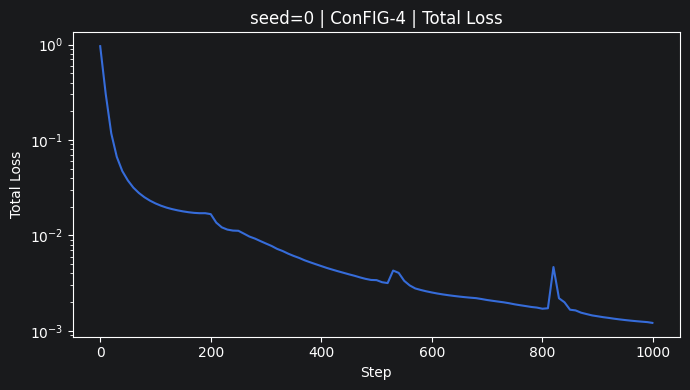

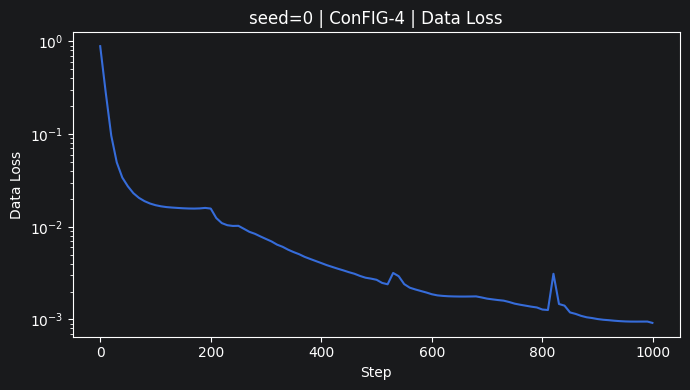

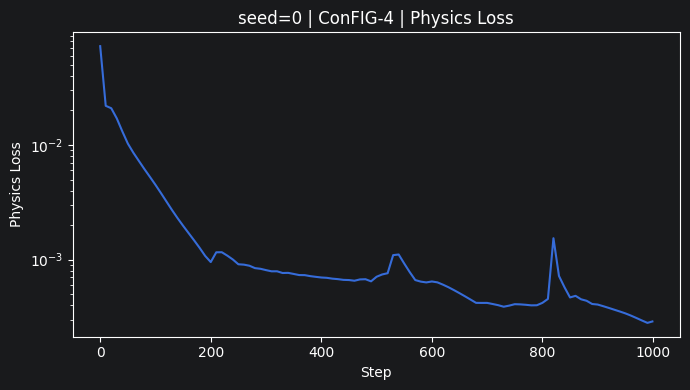

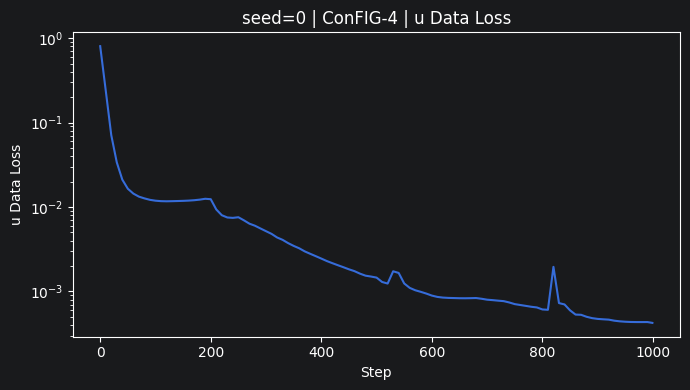

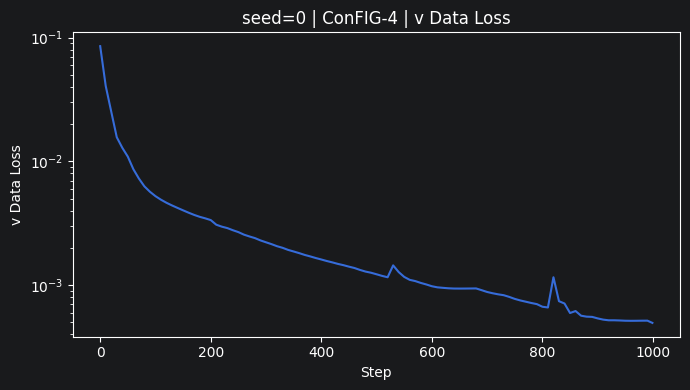

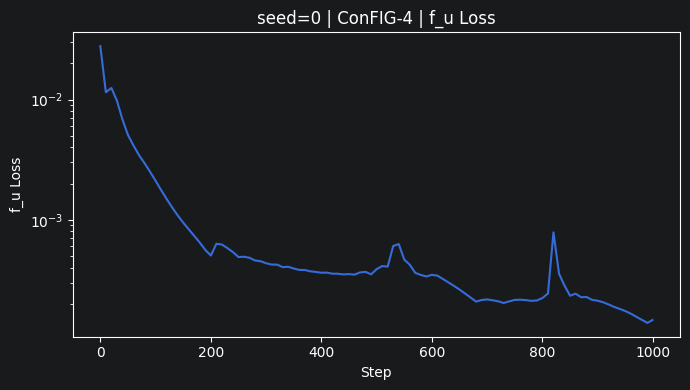

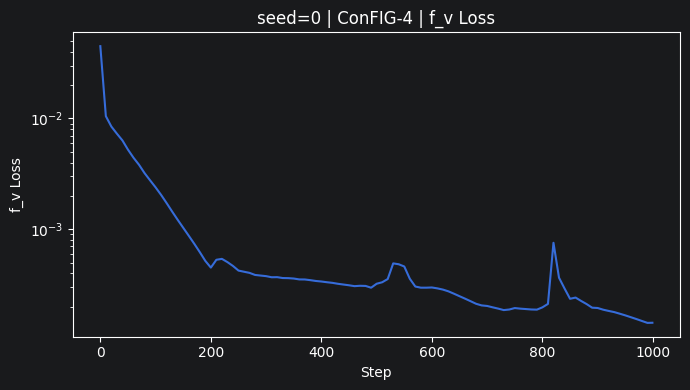

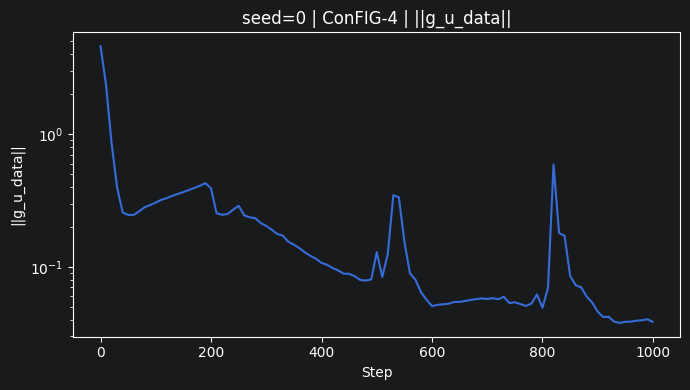

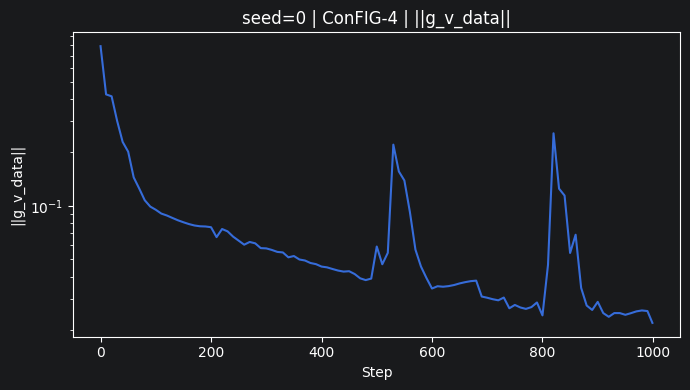

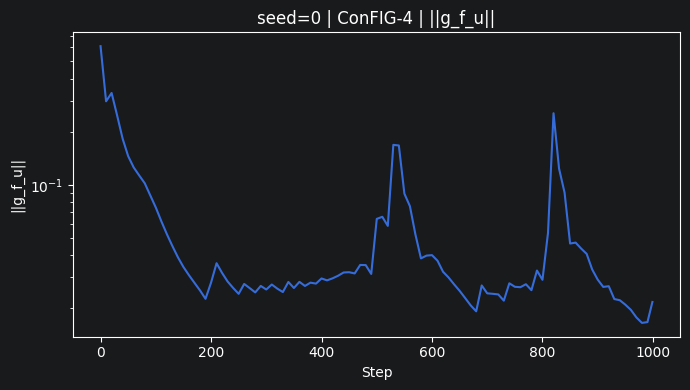

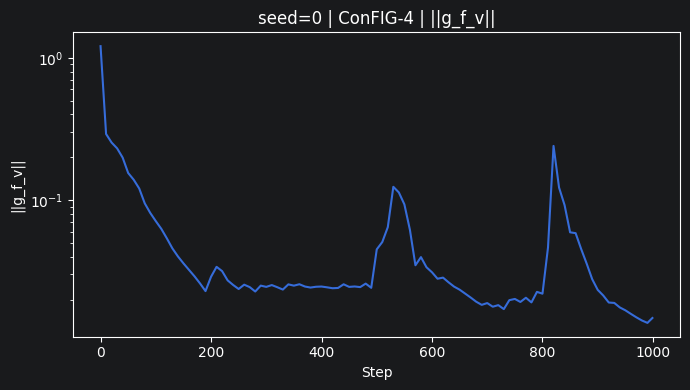

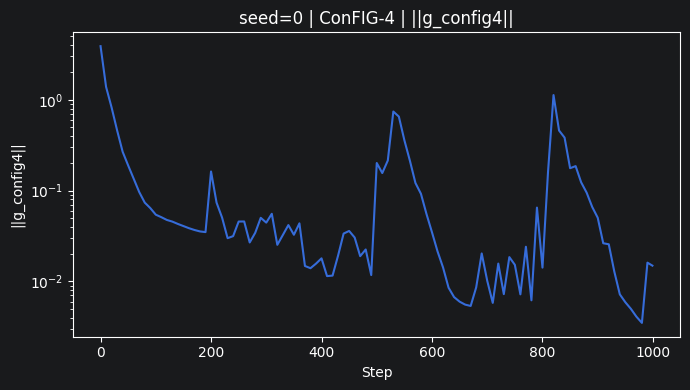

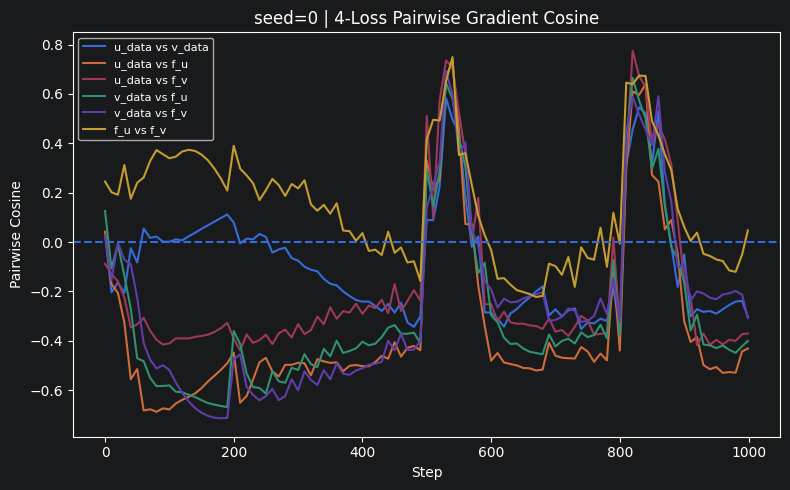

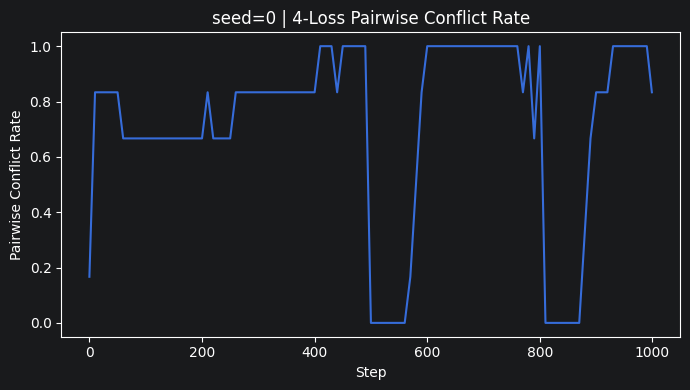

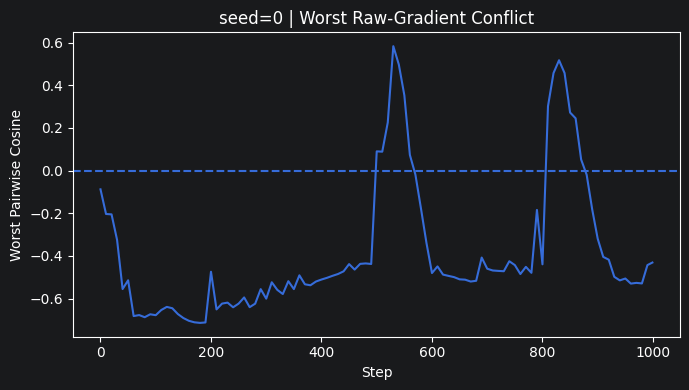

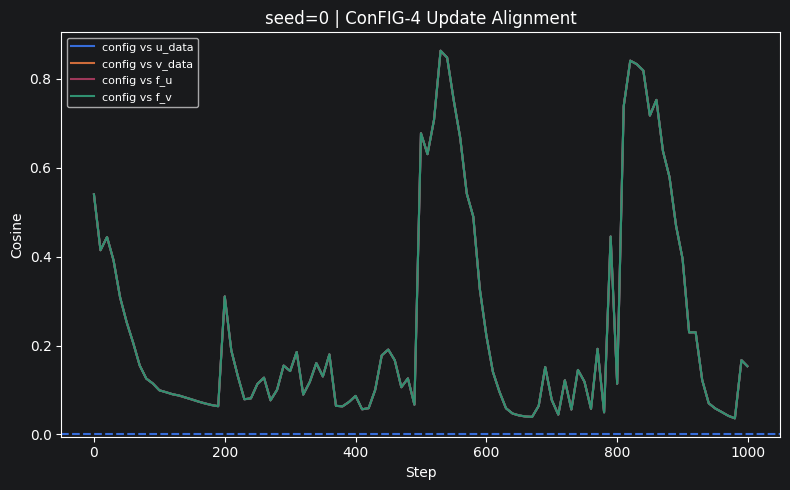

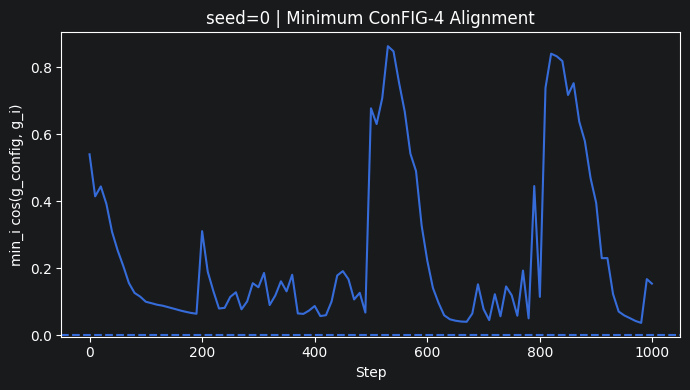

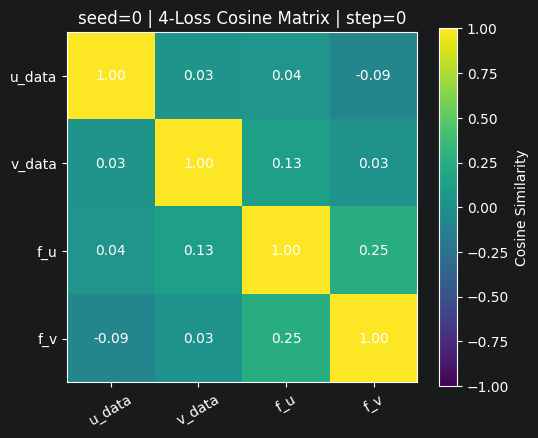

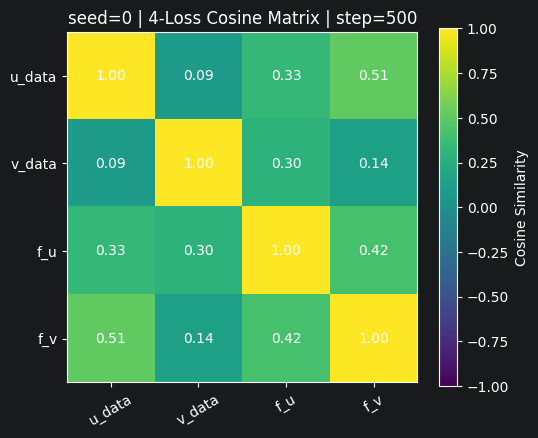

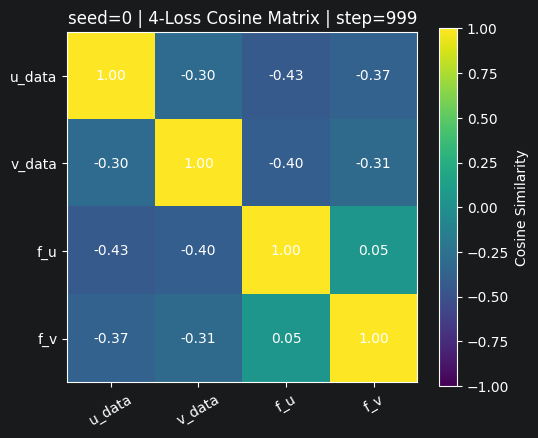

/tmp/ipykernel_118003/3112435597.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(path, map_location=device)


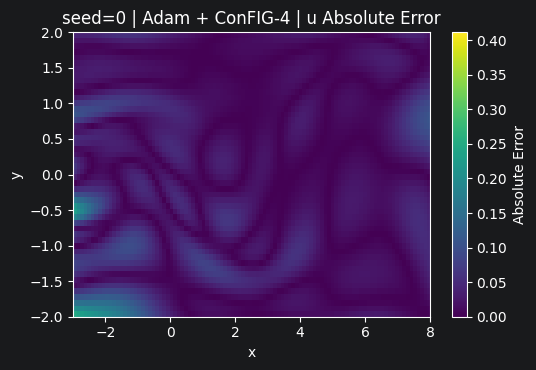

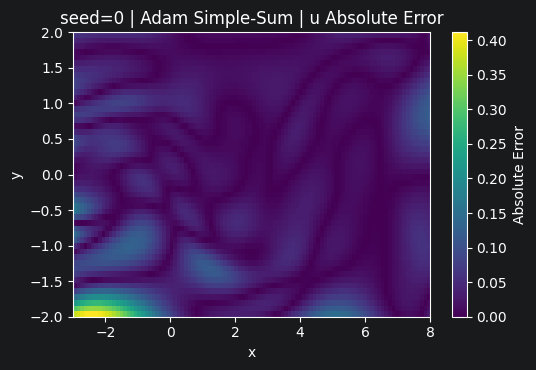

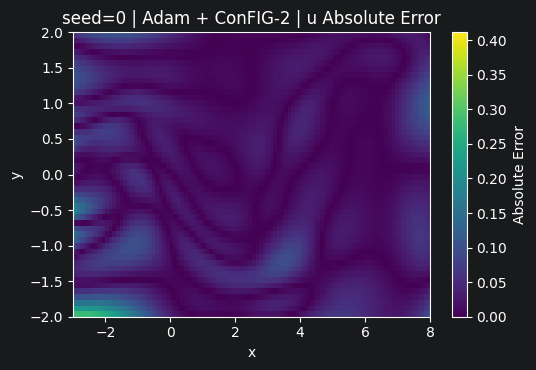

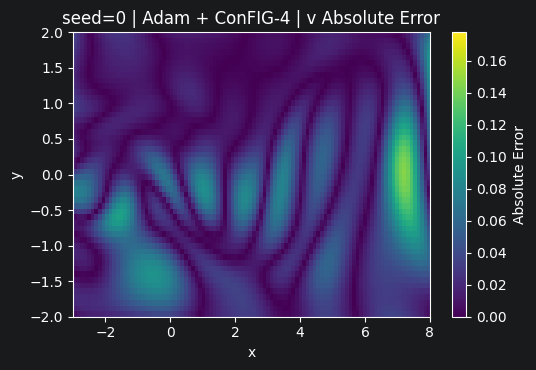

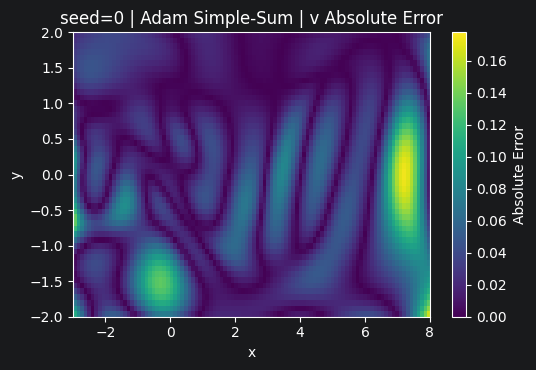

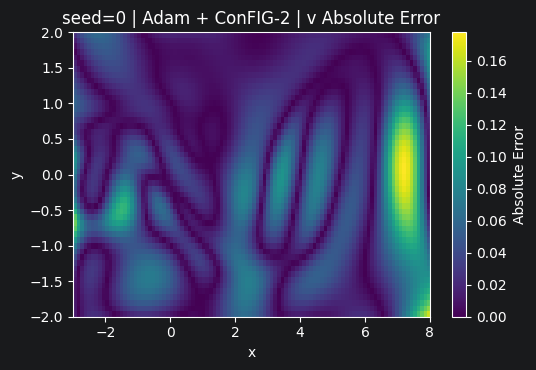

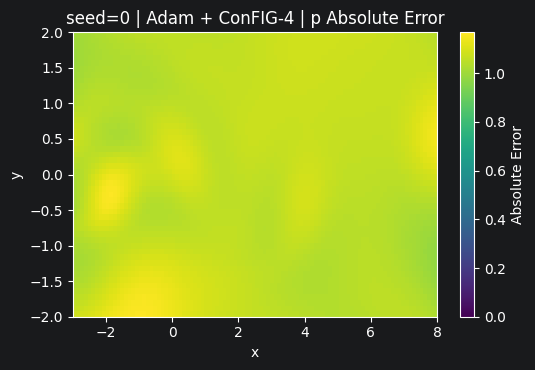

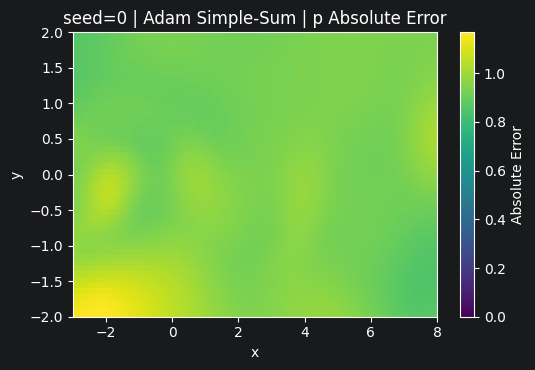

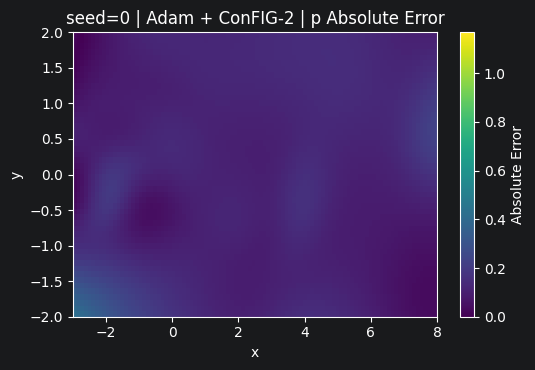

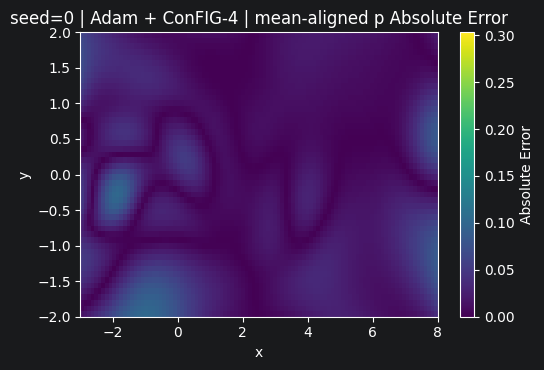

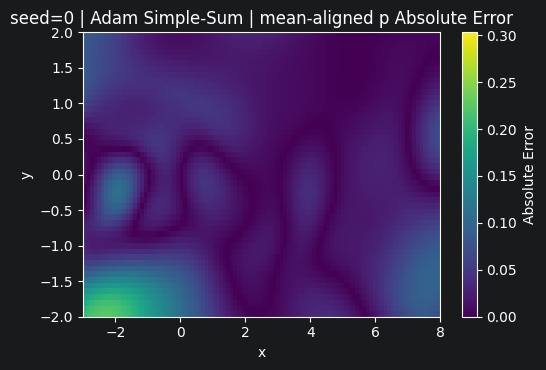

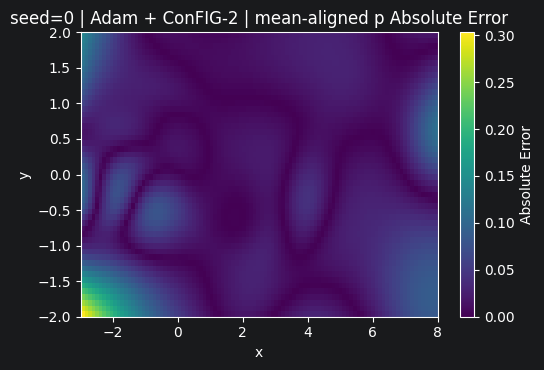


ConFIG-4 | SEED 1

[ConFIG-4] seed=1
params: 454106


ConFIG-4 seed=1: 100%|██████████| 1000/1000 [11:22<00:00,  1.47it/s]


wall time: 682.37s (11.37min)
peak allocated: 8405.25 MiB
task-gradient evaluations: 4000 (4/step)

Field metrics:
seed | method          | field | relative_l2 | mae       | max_absolute_error | mean_aligned_relative_l2
-----+-----------------+-------+-------------+-----------+--------------------+-------------------------
1    | Adam + ConFIG-4 | u     | 0.0406902   | 0.0256915 | 0.190936           |                         
1    | Adam + ConFIG-4 | v     | 0.125868    | 0.025082  | 0.137364           |                         
1    | Adam + ConFIG-4 | p     | 4.49388     | 0.596135  | 0.712396           | 0.252689                

4-loss history / gradient / resource summary:
seed | method          | final_physics_loss | mean_physics_loss | mean_pairwise_cosine | mean_pairwise_conflict_rate | late_pairwise_cosine | late_pairwise_conflict_rate | mean_min_config_alignment | late_min_config_alignment | wall_time_min | peak_vram_mib | task_gradient_evaluations
-----+-----------------+---

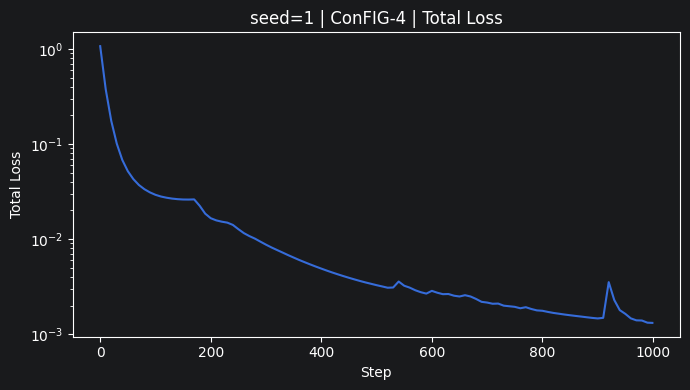

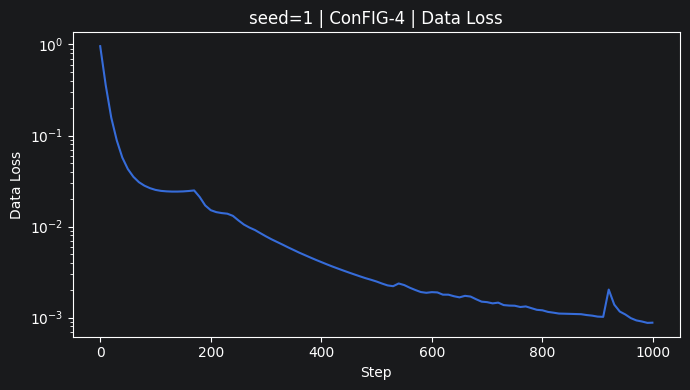

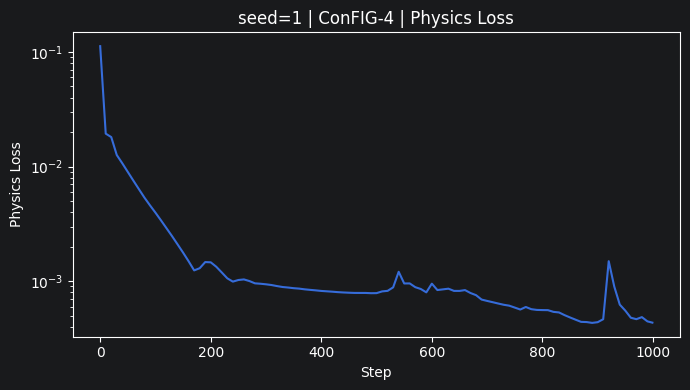

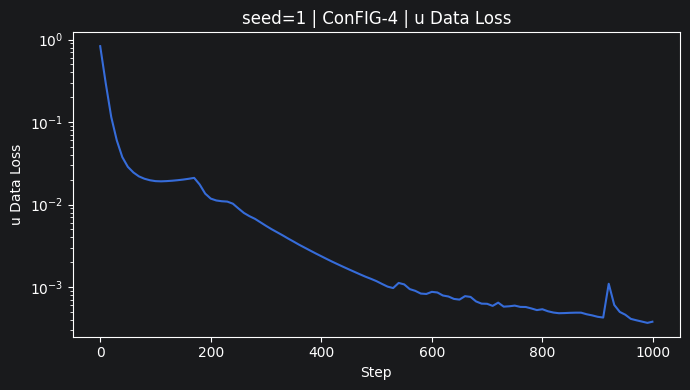

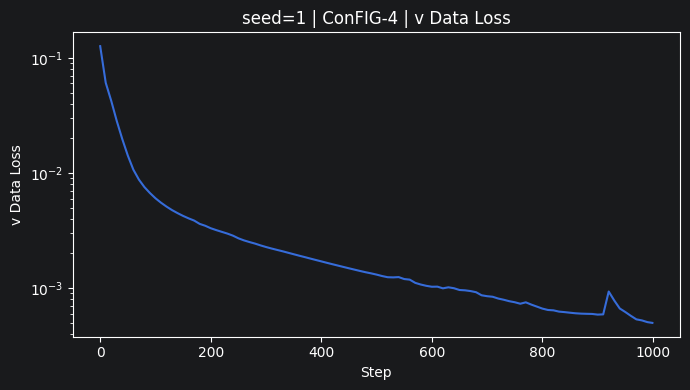

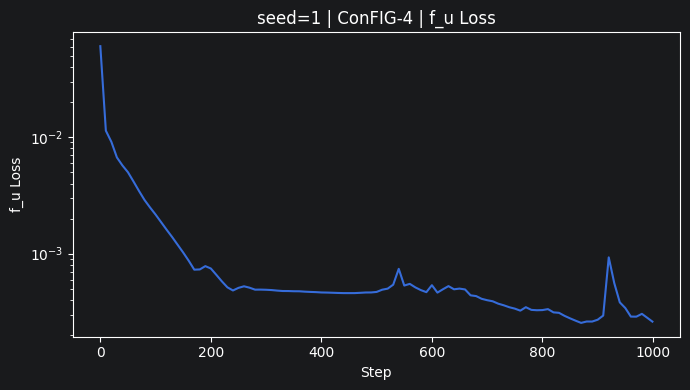

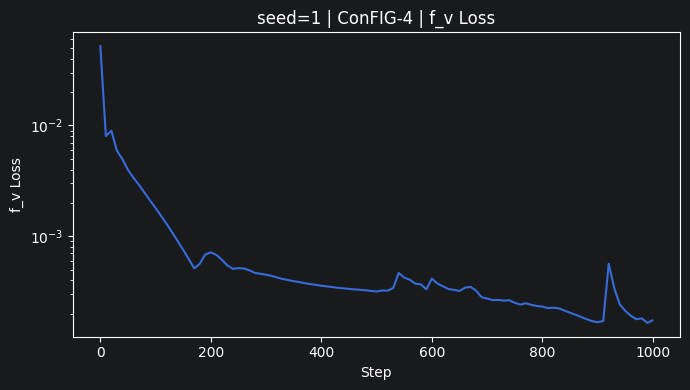

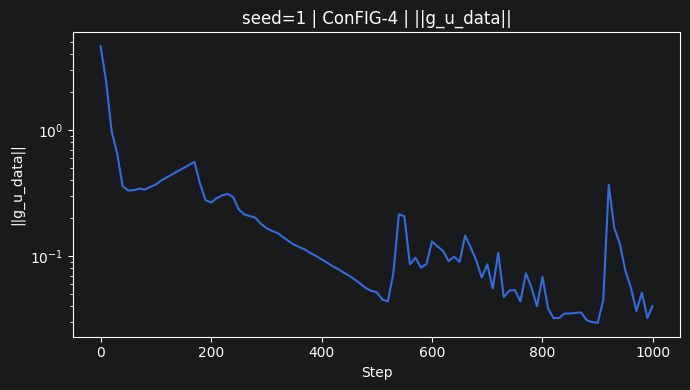

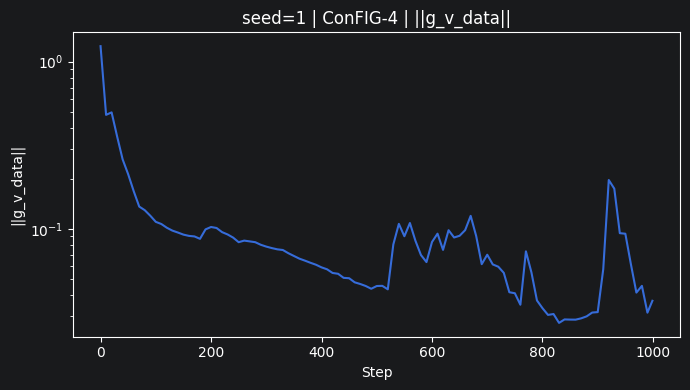

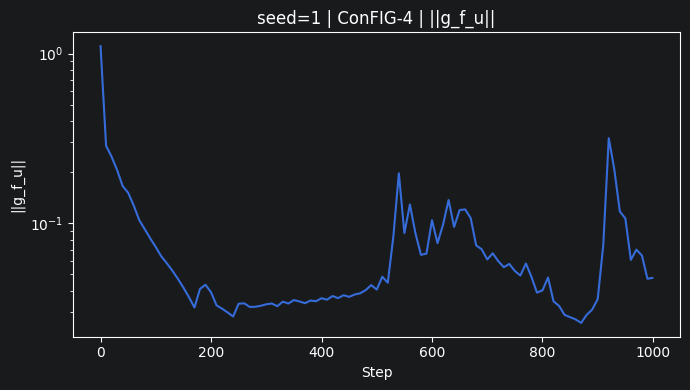

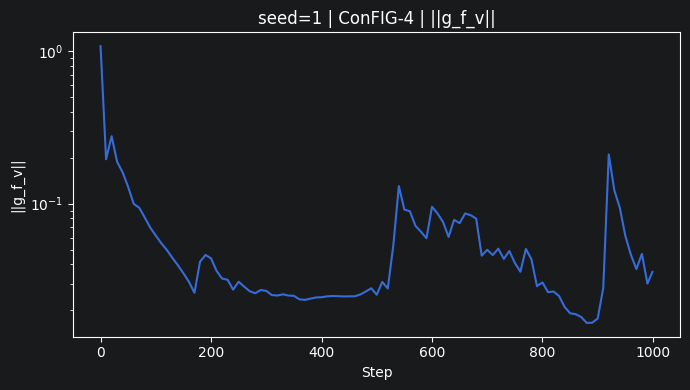

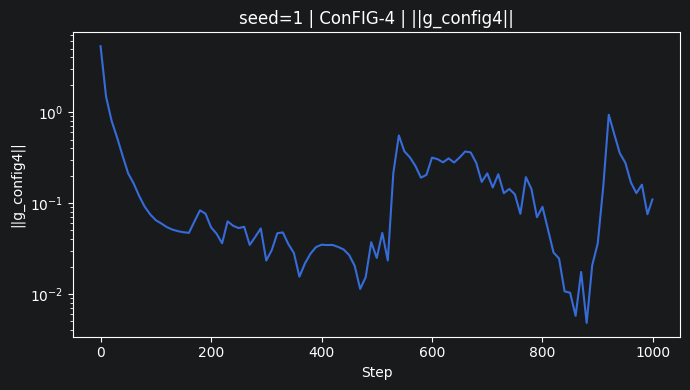

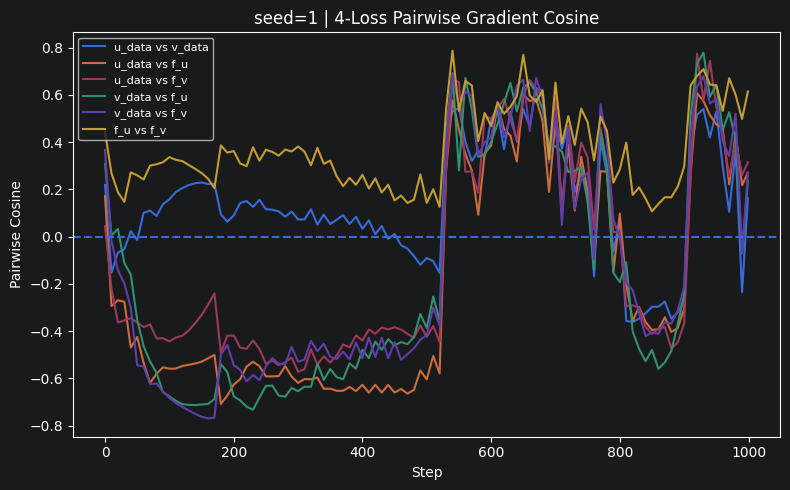

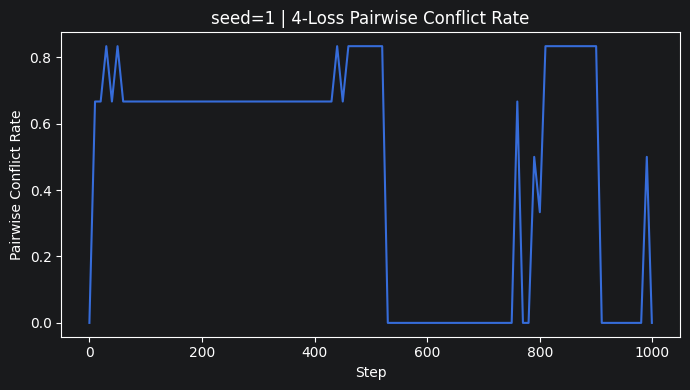

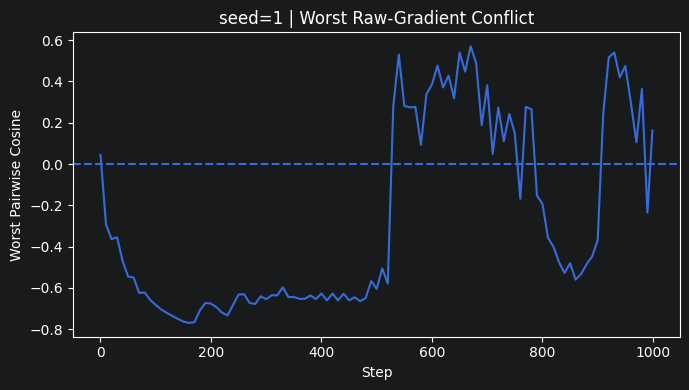

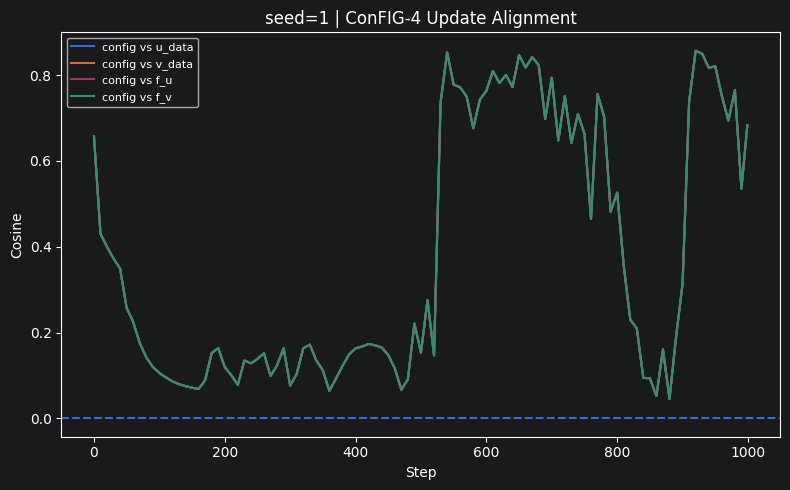

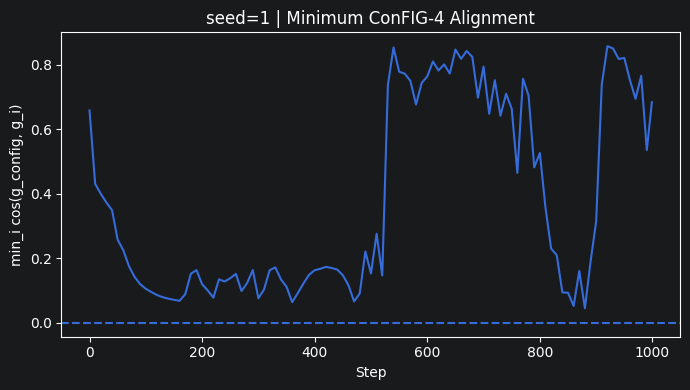

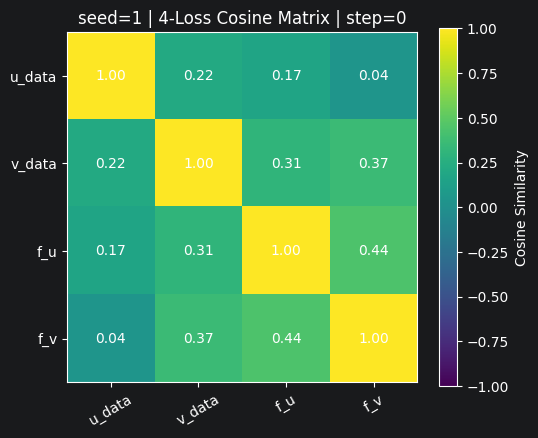

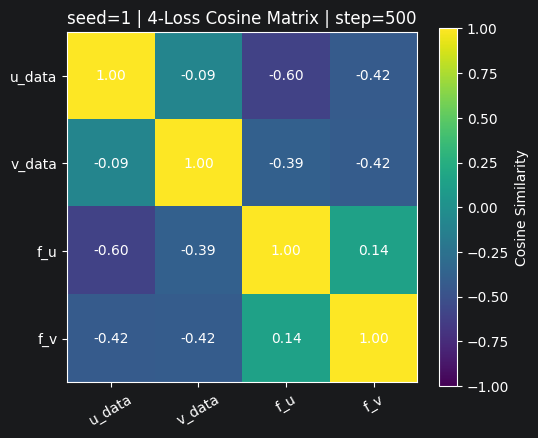

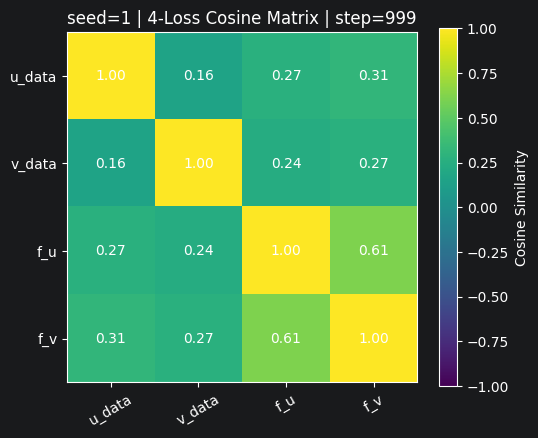

/tmp/ipykernel_118003/3112435597.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(path, map_location=device)


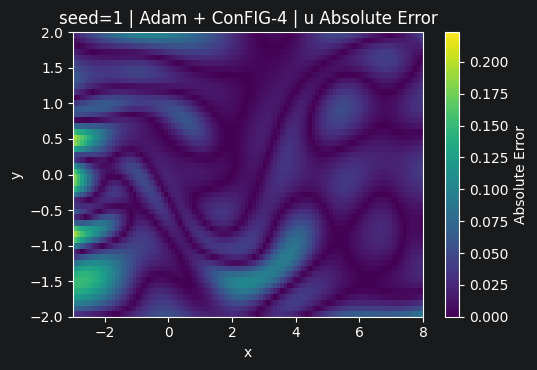

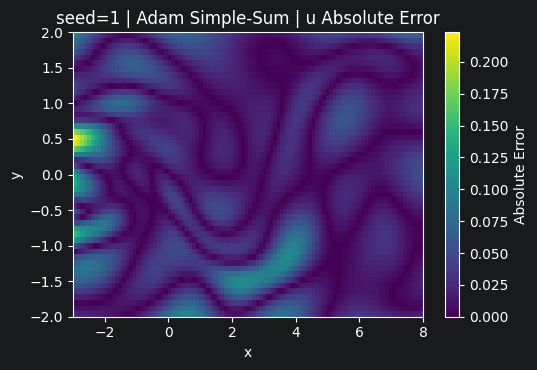

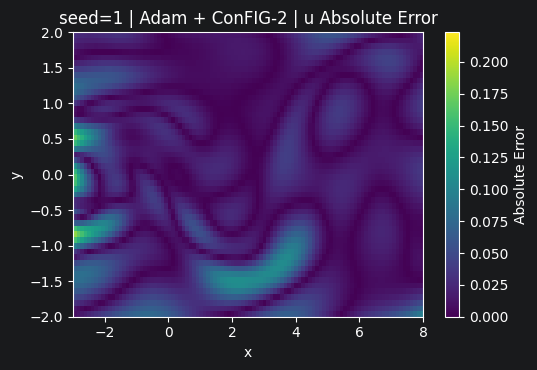

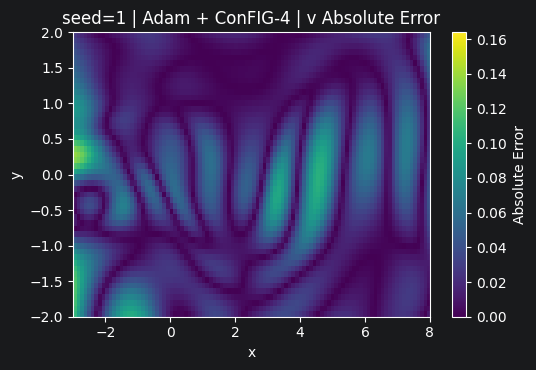

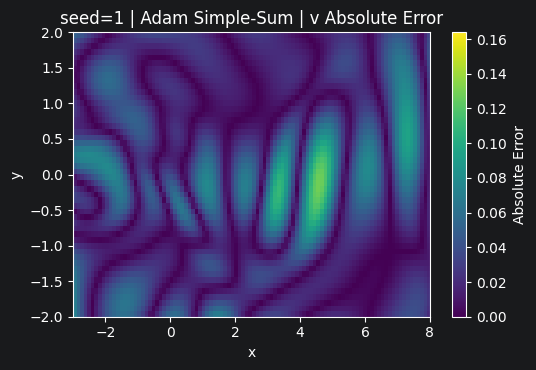

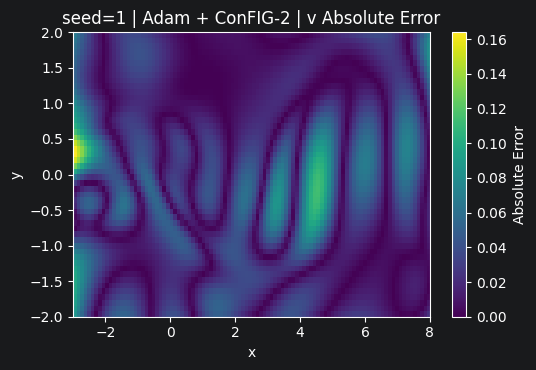

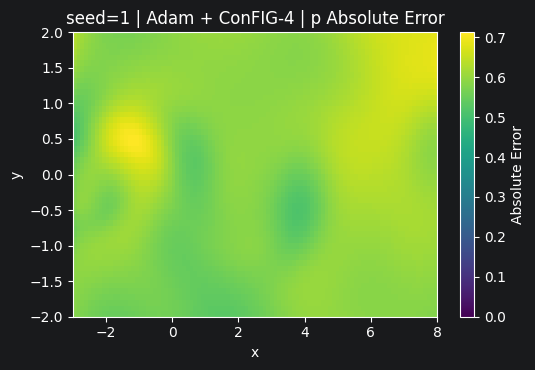

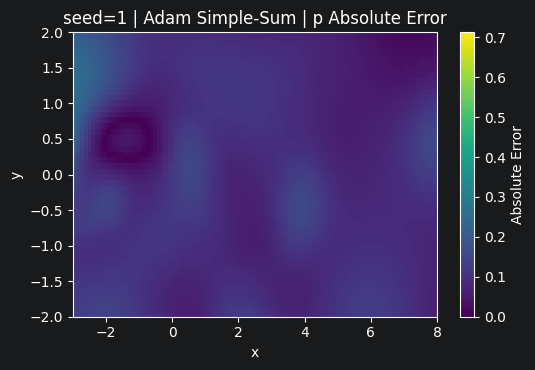

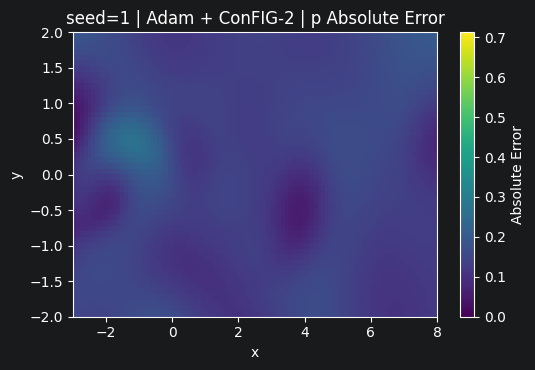

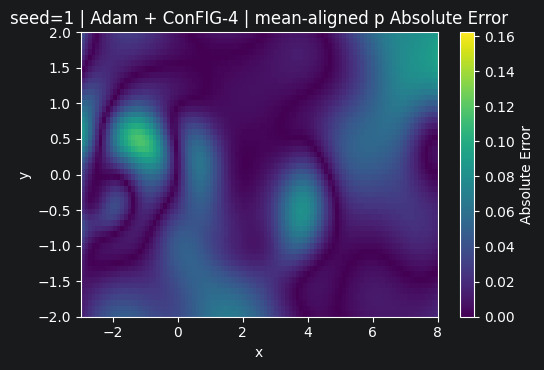

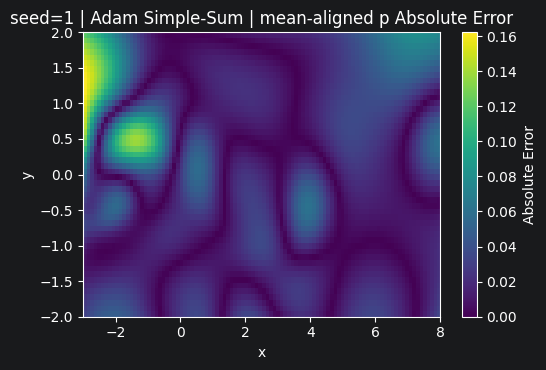

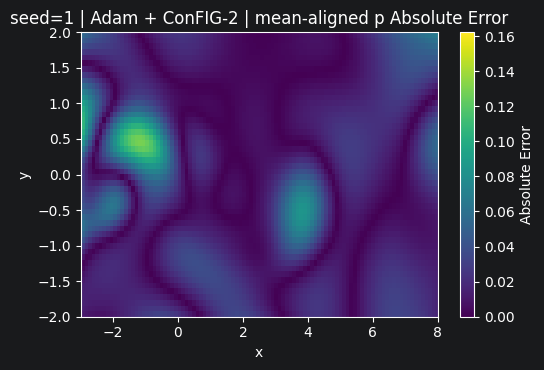


ConFIG-4 | SEED 2

[ConFIG-4] seed=2
params: 454106


ConFIG-4 seed=2: 100%|██████████| 1000/1000 [11:35<00:00,  1.44it/s]


wall time: 695.27s (11.59min)
peak allocated: 8405.25 MiB
task-gradient evaluations: 4000 (4/step)

Field metrics:
seed | method          | field | relative_l2 | mae       | max_absolute_error | mean_aligned_relative_l2
-----+-----------------+-------+-------------+-----------+--------------------+-------------------------
2    | Adam + ConFIG-4 | u     | 0.0318458   | 0.0200148 | 0.197355           |                         
2    | Adam + ConFIG-4 | v     | 0.124024    | 0.02406   | 0.158722           |                         
2    | Adam + ConFIG-4 | p     | 17.7535     | 2.35862   | 2.50981            | 0.228532                

4-loss history / gradient / resource summary:
seed | method          | final_physics_loss | mean_physics_loss | mean_pairwise_cosine | mean_pairwise_conflict_rate | late_pairwise_cosine | late_pairwise_conflict_rate | mean_min_config_alignment | late_min_config_alignment | wall_time_min | peak_vram_mib | task_gradient_evaluations
-----+-----------------+---

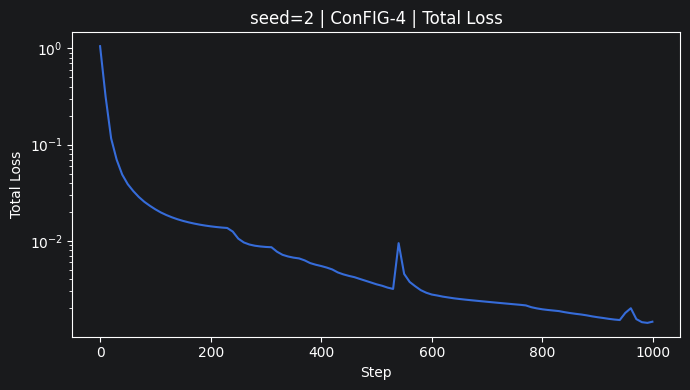

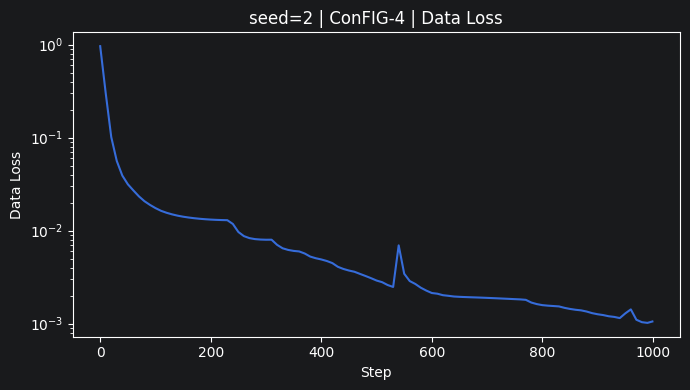

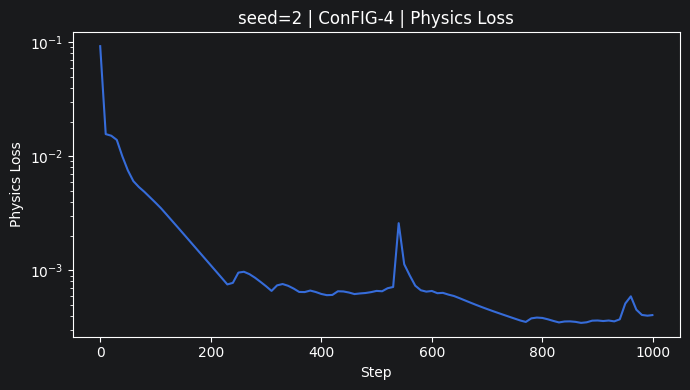

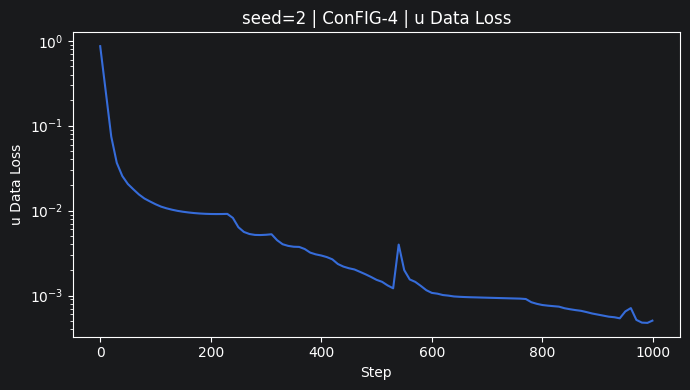

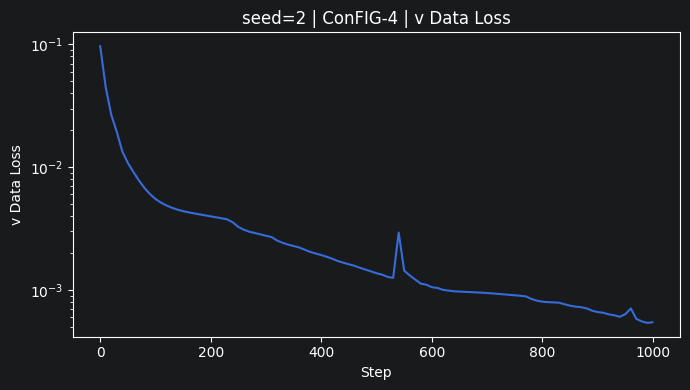

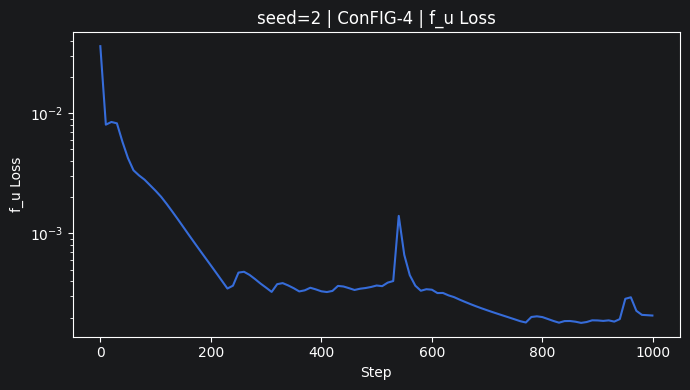

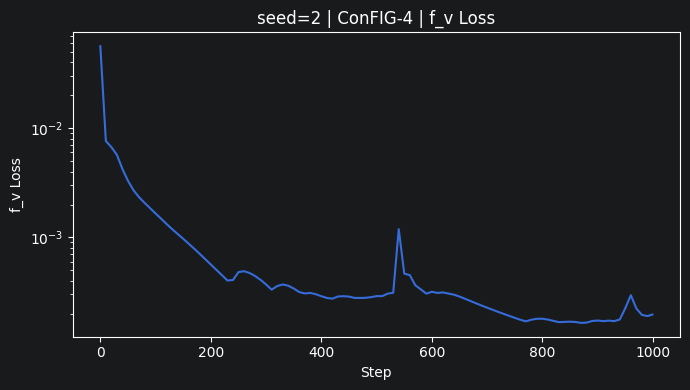

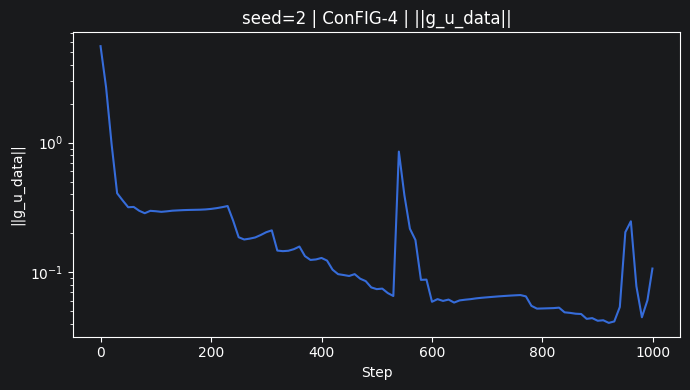

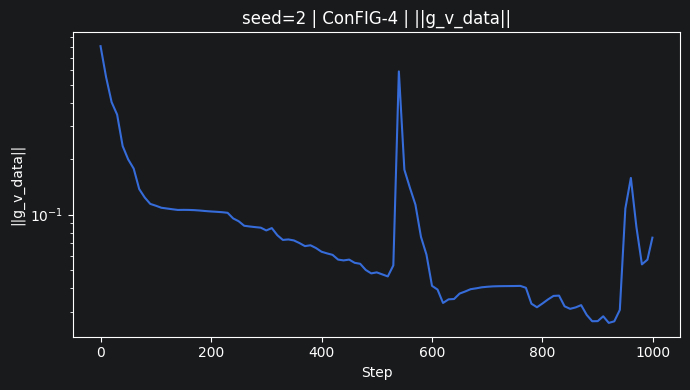

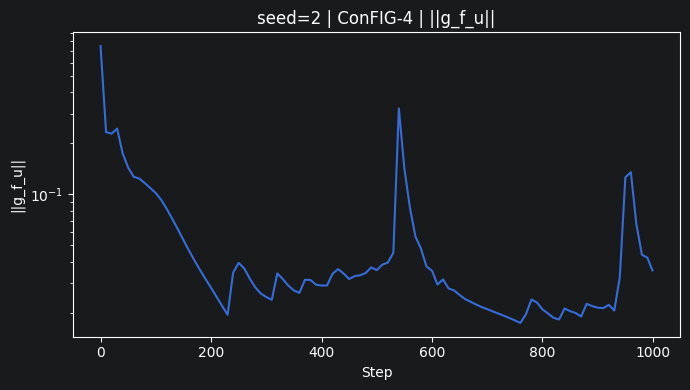

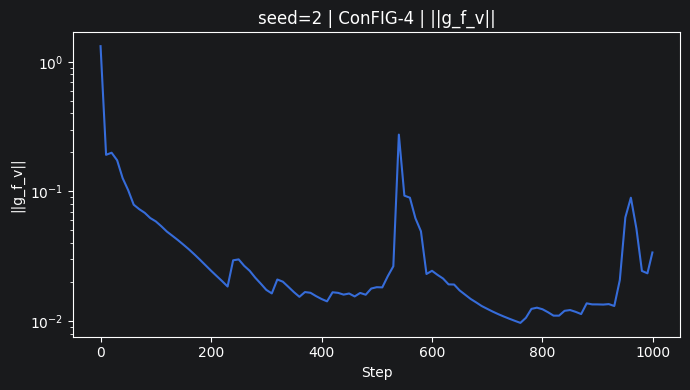

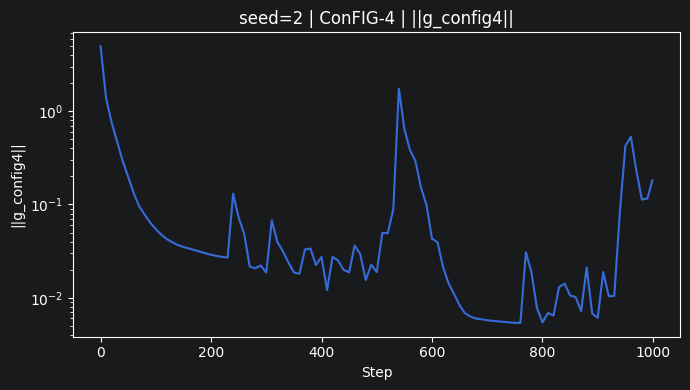

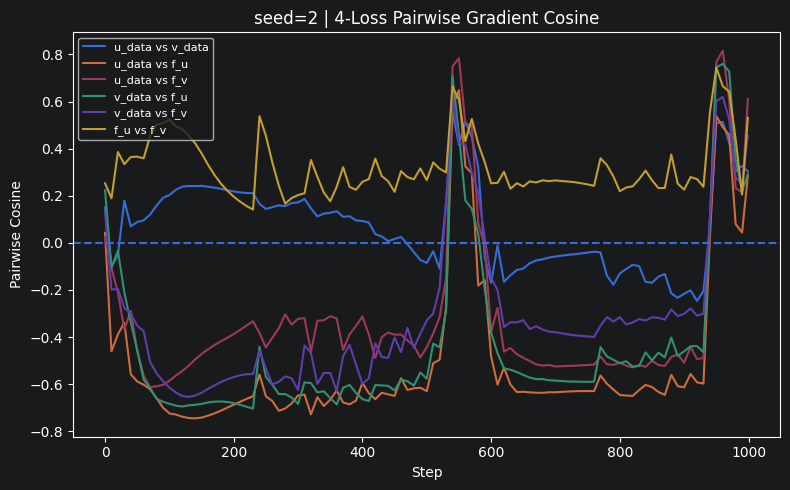

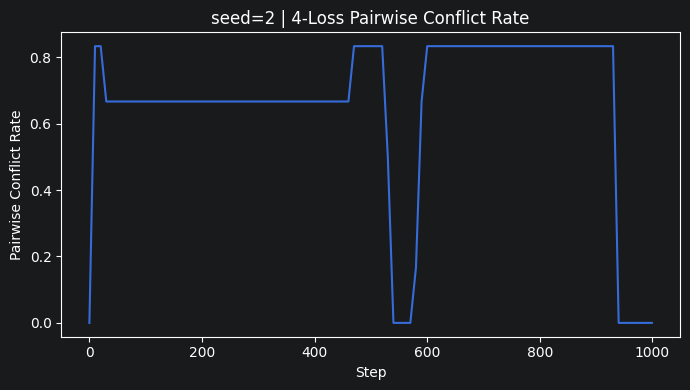

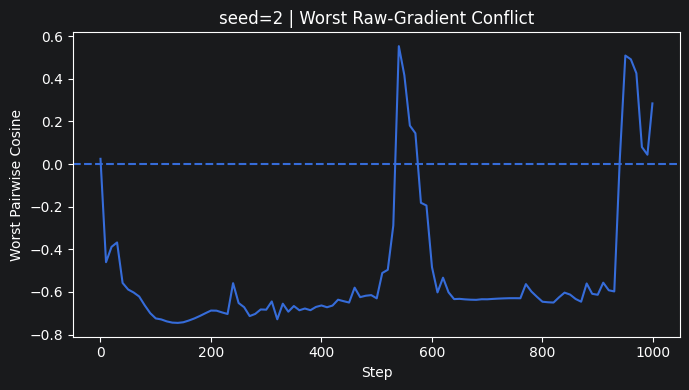

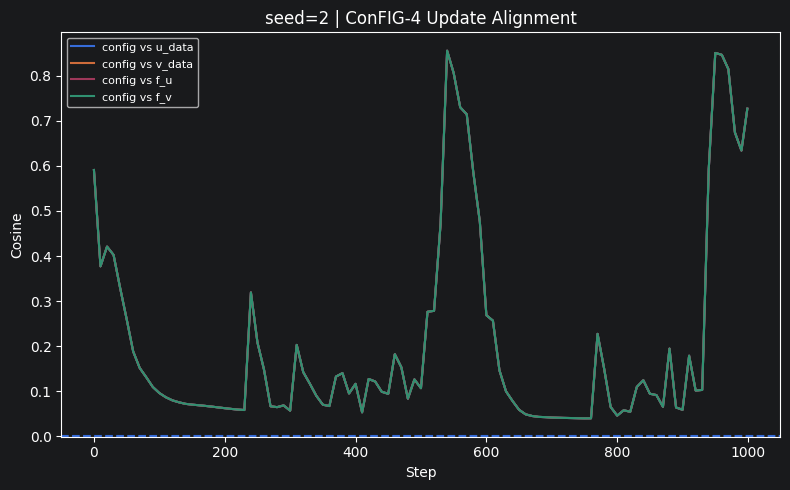

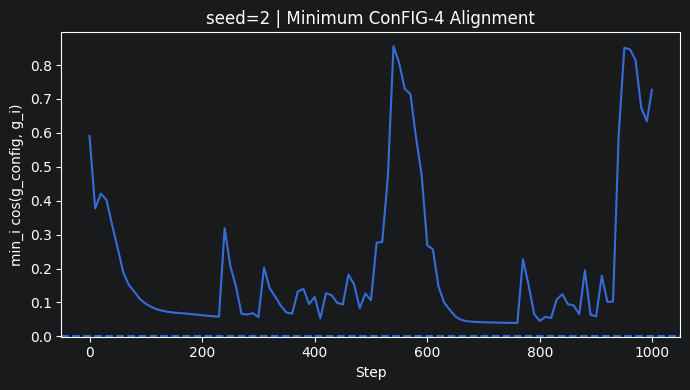

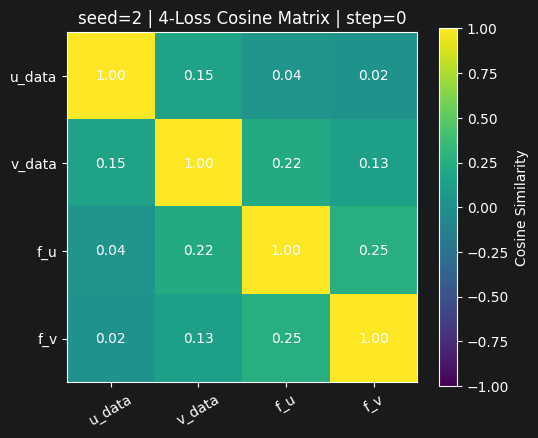

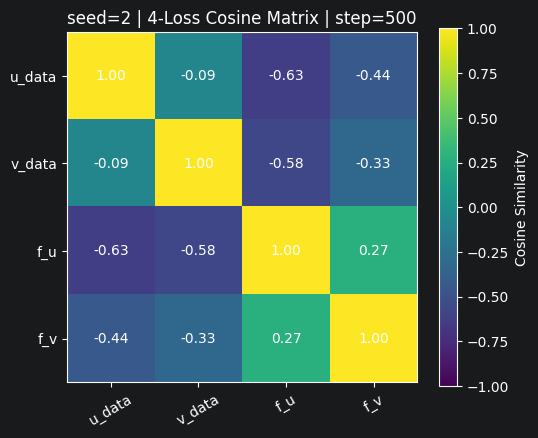

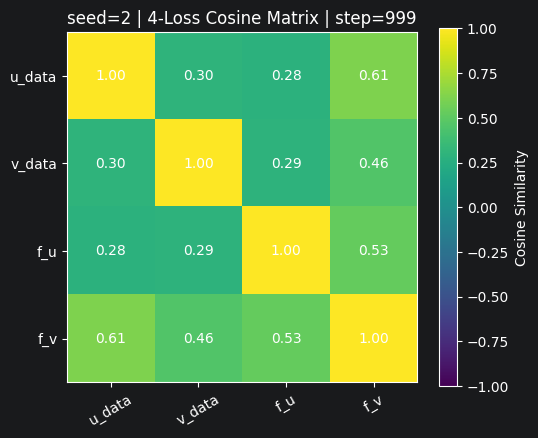

/tmp/ipykernel_118003/3112435597.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(path, map_location=device)


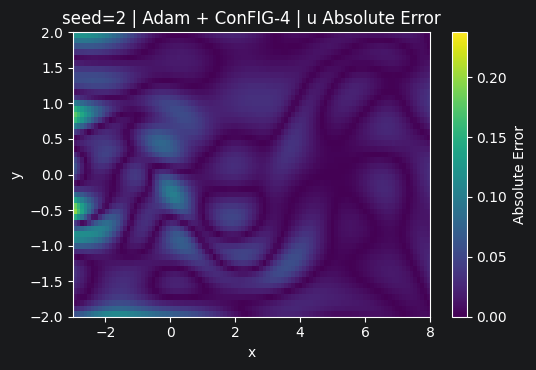

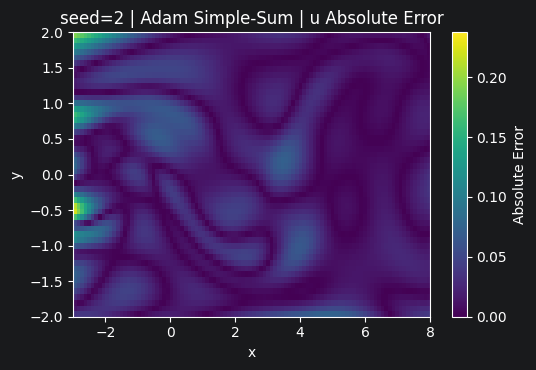

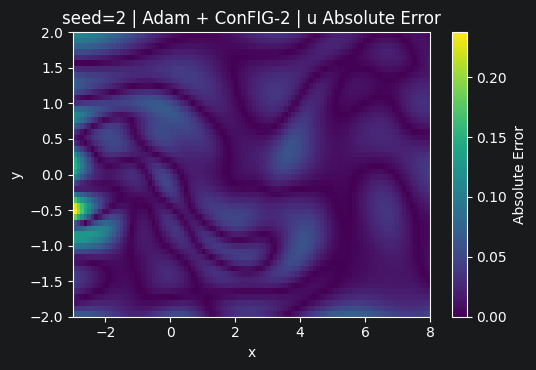

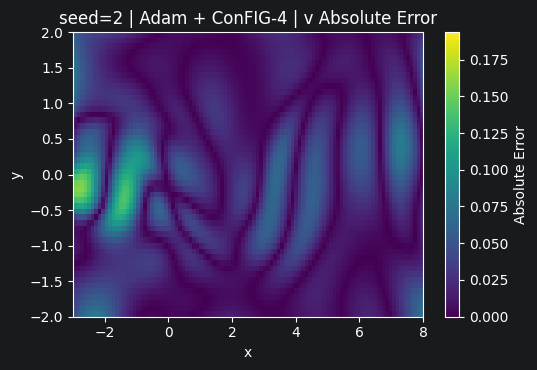

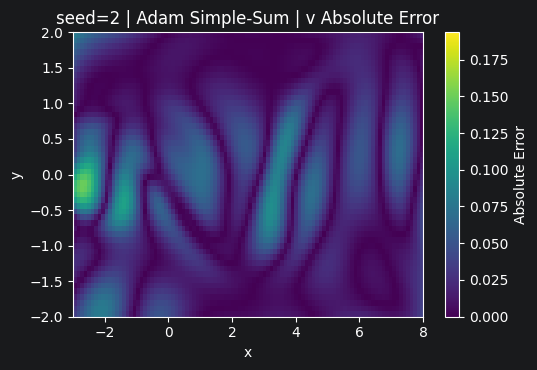

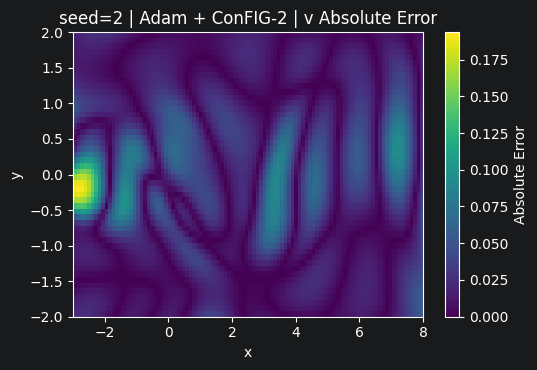

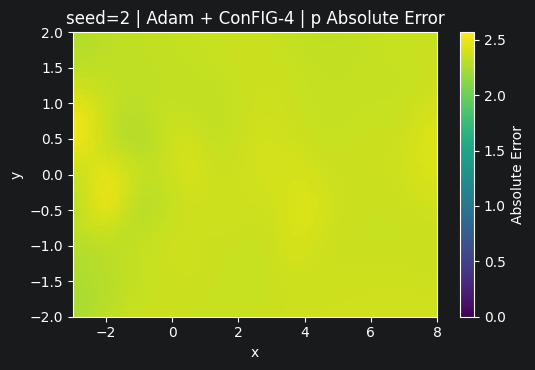

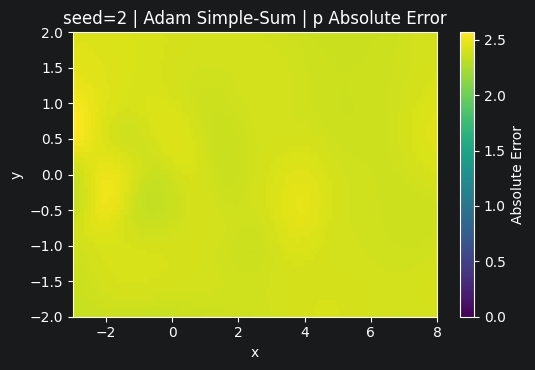

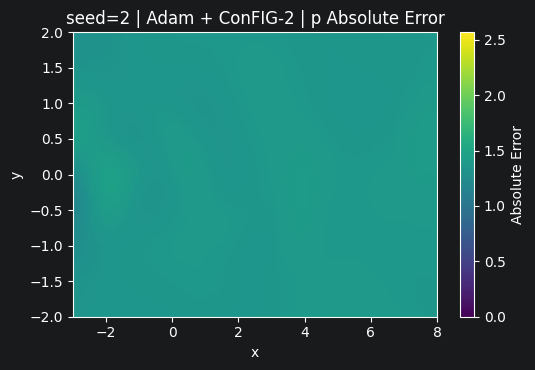

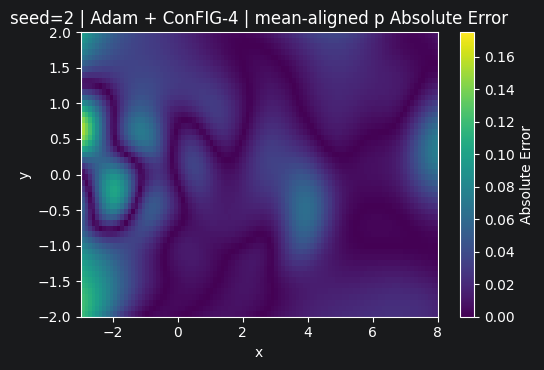

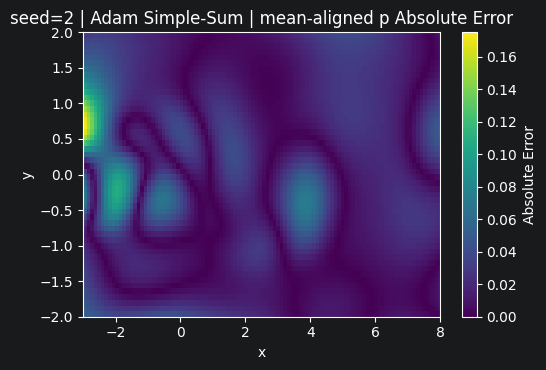

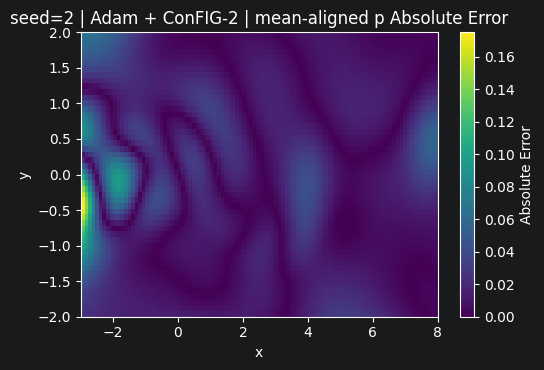


All requested ConFIG-4 seeds finished.


In [13]:

for seed in RUN_SEEDS:
    print("\n" + "=" * 92)
    print(f"ConFIG-4 | SEED {seed}")
    print("=" * 92)

    seed_root = ensure_dir(FOURLOSS_ROOT / f"seed_{seed}")
    method_dir = ensure_dir(seed_root / "config_4loss")
    figure_dir = ensure_dir(seed_root / "figures")

    # 同一 seed 使用与已有实验相同的数据采样规则。
    set_seed(seed)
    batch, reference = load_training_data(
        DATA_PATH,
        device,
        seed=seed,
        n_train=N_TRAIN,
        num_step=NUM_STEP,
        time_step=TIME_STEP,
    )

    complete = all(
        (method_dir / name).exists()
        for name in ["model.pt", "history.npz", "run_meta.json"]
    )

    if complete and not FORCE_RERUN:
        print(f"[seed={seed}] reuse existing ConFIG-4 results")
        h = load_history(method_dir / "history.npz")
        with (method_dir / "run_meta.json").open(
            "r",
            encoding="utf-8",
        ) as f:
            meta = json.load(f)

        model = load_model_checkpoint(
            method_dir / "model.pt",
            seed,
            device,
        )
    else:
        try:
            model, history_list, meta = train_config4(
                seed,
                batch,
                device,
                method_dir,
            )
        except torch.cuda.OutOfMemoryError:
            print("\nCUDA OOM during ConFIG-4 training.")
            print(
                "Restart the kernel and rerun only this notebook before "
                "changing N_TRAIN. Do not compare a reduced-point run "
                "against the existing 800-point baselines as a formal result."
            )
            raise

        h = history_dict(history_list)

    # ---------- Evaluation ----------
    ev, truth = evaluation_truth(reference, device)
    pred4 = predict_fields(model, ev)

    field_rows = field_metrics(
        seed,
        "Adam + ConFIG-4",
        truth,
        pred4,
    )

    write_dict_rows_csv(
        method_dir / "field_metrics.csv",
        field_rows,
    )
    save_predictions(
        method_dir / "predictions.npz",
        truth,
        pred4,
    )

    history_row = summarize_config4_history(
        seed,
        h,
        meta,
    )
    threshold_seed_rows = threshold_rows(seed, h)

    write_dict_rows_csv(
        method_dir / "history_summary.csv",
        [history_row],
    )
    write_dict_rows_csv(
        method_dir / "threshold_steps.csv",
        threshold_seed_rows,
    )

    # 保存 101 个 sampled steps 的细粒度 gradient diagnostics。
    gradient_columns = [
        "step",
        "g_u_data_norm",
        "g_v_data_norm",
        "g_f_u_norm",
        "g_f_v_norm",
        "g_config_norm",
    ]
    gradient_columns += [
        f"cos_{a}__{b}" for a, b in PAIR_NAMES
    ]
    gradient_columns += [
        "mean_pairwise_cosine",
        "min_pairwise_cosine",
        "pairwise_conflict_rate",
        "mean_negative_cosine",
        "conflict_degree_u_data",
        "conflict_degree_v_data",
        "conflict_degree_f_u",
        "conflict_degree_f_v",
        "cos_config__u_data",
        "cos_config__v_data",
        "cos_config__f_u",
        "cos_config__f_v",
        "min_config_alignment",
        "mean_config_alignment",
        "config_nonpositive_alignment_rate",
    ]

    sampled_gradient_rows = []
    for idx in range(len(h["step"])):
        sampled_gradient_rows.append(
            {
                col: (
                    int(h[col][idx])
                    if col == "step"
                    else float(h[col][idx])
                )
                for col in gradient_columns
            }
        )

    write_dict_rows_csv(
        method_dir / "gradient_diagnostics.csv",
        sampled_gradient_rows,
        fieldnames=gradient_columns,
    )

    print("\nField metrics:")
    print_table(
        field_rows,
        columns=[
            "seed",
            "method",
            "field",
            "relative_l2",
            "mae",
            "max_absolute_error",
            "mean_aligned_relative_l2",
        ],
    )

    print("\n4-loss history / gradient / resource summary:")
    print_table(
        [history_row],
        columns=[
            "seed",
            "method",
            "final_physics_loss",
            "mean_physics_loss",
            "mean_pairwise_cosine",
            "mean_pairwise_conflict_rate",
            "late_pairwise_cosine",
            "late_pairwise_conflict_rate",
            "mean_min_config_alignment",
            "late_min_config_alignment",
            "wall_time_min",
            "peak_vram_mib",
            "task_gradient_evaluations",
        ],
    )

    print("\nPhysics threshold crossing:")
    print_table(
        threshold_seed_rows,
        columns=[
            "seed",
            "threshold",
            "first_sampled_step_below",
        ],
    )

    # ---------- Curves ----------
    plot_seed_config4_curves(
        seed,
        h,
        figure_dir,
    )

    # step=0 / approximately mid / last cosine matrices.
    for idx in [0, len(h["step"]) // 2, len(h["step"]) - 1]:
        row = {key: h[key][idx] for key in h}
        plot_cosine_heatmap(
            seed,
            row,
            int(h["step"][idx]),
            figure_dir,
        )

    # ---------- Absolute Error ----------
    # 如果旧 checkpoint 可用，画 Adam / ConFIG-2 / ConFIG-4 同尺度图；
    # 否则至少画 ConFIG-4。
    preds_by_method = {
        "Adam + ConFIG-4": pred4,
    }

    for old_method in ["Adam Simple-Sum", "Adam + ConFIG-2"]:
        ckpt = existing_checkpoint(seed, old_method)
        old_model = load_model_checkpoint(
            ckpt,
            seed,
            device,
        )
        if old_model is None:
            print("missing old checkpoint; skip abs-error:", ckpt)
            continue

        ev_old, _ = evaluation_truth(reference, device)
        old_pred = predict_fields(old_model, ev_old)
        preds_by_method[old_method] = old_pred

        del old_model, ev_old
        gc.collect()
        torch.cuda.empty_cache()

    plot_absolute_errors(
        seed,
        truth,
        preds_by_method,
        figure_dir,
    )

    del model, ev, batch, reference
    gc.collect()
    torch.cuda.empty_cache()

print("\nAll requested ConFIG-4 seeds finished.")


## 13. 聚合 3 个 ConFIG-4 seeds

In [14]:

AGG_DIR = ensure_dir(FOURLOSS_ROOT / "aggregate")

all_field_rows = []
all_history_rows = []
all_threshold_rows = []
completed_seeds = []

for seed in RUN_SEEDS:
    method_dir = (
        FOURLOSS_ROOT
        / f"seed_{seed}"
        / "config_4loss"
    )

    required = [
        method_dir / "field_metrics.csv",
        method_dir / "history_summary.csv",
        method_dir / "threshold_steps.csv",
        method_dir / "run_meta.json",
    ]

    if not all(p.exists() for p in required):
        print(f"skip incomplete seed={seed}")
        continue

    completed_seeds.append(seed)

    field_rows = read_dict_rows_csv(
        method_dir / "field_metrics.csv"
    )
    for row in field_rows:
        row["seed"] = int(row["seed"])
        for key in [
            "relative_l2",
            "mae",
            "max_absolute_error",
        ]:
            row[key] = float(row[key])
        if row["mean_aligned_relative_l2"] != "":
            row["mean_aligned_relative_l2"] = float(
                row["mean_aligned_relative_l2"]
            )
        all_field_rows.append(row)

    history_rows = read_dict_rows_csv(
        method_dir / "history_summary.csv"
    )
    for row in history_rows:
        row["seed"] = int(row["seed"])
        for key in row:
            if key not in ["seed", "method"]:
                row[key] = float(row[key])
        all_history_rows.append(row)

    threshold_seed_rows = read_dict_rows_csv(
        method_dir / "threshold_steps.csv"
    )
    for row in threshold_seed_rows:
        row["seed"] = int(row["seed"])
        row["threshold"] = float(row["threshold"])
        row["first_sampled_step_below"] = float(
            row["first_sampled_step_below"]
        )
        all_threshold_rows.append(row)

print("completed seeds:", completed_seeds)

write_dict_rows_csv(
    AGG_DIR / "all_field_metrics_config4.csv",
    all_field_rows,
)
write_dict_rows_csv(
    AGG_DIR / "all_history_metrics_config4.csv",
    all_history_rows,
)
write_dict_rows_csv(
    AGG_DIR / "all_threshold_steps_config4.csv",
    all_threshold_rows,
)


completed seeds: [0, 1, 2]


## 14. ConFIG-4 mean ± std

In [15]:

def field_values(field, key):
    values = []
    for row in all_field_rows:
        if row["field"] != field:
            continue
        value = row.get(key, "")
        if value == "" or value is None:
            continue
        values.append(float(value))
    return values


def history_values(key):
    return [
        float(row[key])
        for row in all_history_rows
        if np.isfinite(float(row[key]))
    ]


summary4_rows = []

for metric, field, key in [
    ("u_relative_l2", "u", "relative_l2"),
    ("v_relative_l2", "v", "relative_l2"),
    ("p_raw_relative_l2", "p", "relative_l2"),
    (
        "p_mean_aligned_relative_l2",
        "p",
        "mean_aligned_relative_l2",
    ),
]:
    vals = field_values(field, key)
    summary4_rows.append(
        {
            "metric": metric,
            "method": "Adam + ConFIG-4",
            "n": len(vals),
            "mean": safe_mean(vals) if vals else np.nan,
            "std": safe_std(vals) if vals else np.nan,
        }
    )

for key in [
    "final_total_loss",
    "final_data_loss",
    "final_physics_loss",
    "mean_total_loss",
    "mean_data_loss",
    "mean_physics_loss",
    "mean_pairwise_cosine",
    "mean_pairwise_conflict_rate",
    "late_pairwise_cosine",
    "late_pairwise_conflict_rate",
    "mean_min_config_alignment",
    "late_min_config_alignment",
    "nonpositive_config_alignment_rate",
    "wall_time_min",
    "peak_vram_mib",
    "task_gradient_evaluations",
]:
    vals = history_values(key)
    summary4_rows.append(
        {
            "metric": key,
            "method": "Adam + ConFIG-4",
            "n": len(vals),
            "mean": safe_mean(vals) if vals else np.nan,
            "std": safe_std(vals) if vals else np.nan,
        }
    )

write_dict_rows_csv(
    AGG_DIR / "mean_std_summary_config4.csv",
    summary4_rows,
)

print_table(
    summary4_rows,
    columns=["metric", "method", "n", "mean", "std"],
)


metric                            | method          | n | mean        | std        
----------------------------------+-----------------+---+-------------+------------
u_relative_l2                     | Adam + ConFIG-4 | 3 | 0.0378612   | 0.00521255 
v_relative_l2                     | Adam + ConFIG-4 | 3 | 0.129631    | 0.00816681 
p_raw_relative_l2                 | Adam + ConFIG-4 | 3 | 10.084      | 6.86999    
p_mean_aligned_relative_l2        | Adam + ConFIG-4 | 3 | 0.229962    | 0.022047   
final_total_loss                  | Adam + ConFIG-4 | 3 | 0.00132609  | 0.000124165
final_data_loss                   | Adam + ConFIG-4 | 3 | 0.000949768 | 9.02922e-05
final_physics_loss                | Adam + ConFIG-4 | 3 | 0.000376324 | 7.68945e-05
mean_total_loss                   | Adam + ConFIG-4 | 3 | 0.0231915   | 0.00224409 
mean_data_loss                    | Adam + ConFIG-4 | 3 | 0.0205574   | 0.00205462 
mean_physics_loss                 | Adam + ConFIG-4 | 3 | 0.00263412  | 0.00

## 15. 4-loss 每一对冲突的跨 seed 汇总

In [16]:

pair_summary_rows = []

for a, b in PAIR_NAMES:
    key = f"cos_{a}__{b}"
    per_seed_means = []

    for seed in completed_seeds:
        h = load_history(
            FOURLOSS_ROOT
            / f"seed_{seed}"
            / "config_4loss"
            / "history.npz"
        )
        per_seed_means.append(safe_mean(h[key]))

    pair_summary_rows.append(
        {
            "pair": f"{a} vs {b}",
            "n_seed": len(per_seed_means),
            "mean_of_seed_means": (
                safe_mean(per_seed_means)
                if per_seed_means else np.nan
            ),
            "std_of_seed_means": (
                safe_std(per_seed_means)
                if per_seed_means else np.nan
            ),
            "negative_seed_mean_count": int(
                np.sum(np.asarray(per_seed_means) < 0)
            ) if per_seed_means else 0,
        }
    )

write_dict_rows_csv(
    AGG_DIR / "pairwise_cosine_mean_std.csv",
    pair_summary_rows,
)

print("Pairwise cosine, averaged within seed then across seeds:")
print_table(
    pair_summary_rows,
    columns=[
        "pair",
        "n_seed",
        "mean_of_seed_means",
        "std_of_seed_means",
        "negative_seed_mean_count",
    ],
)


Pairwise cosine, averaged within seed then across seeds:
pair             | n_seed | mean_of_seed_means | std_of_seed_means | negative_seed_mean_count
-----------------+--------+--------------------+-------------------+-------------------------
u_data vs v_data | 3      | 0.0407408          | 0.114474          | 1                       
u_data vs f_u    | 3      | -0.349734          | 0.153708          | 3                       
u_data vs f_v    | 3      | -0.202944          | 0.109107          | 3                       
v_data vs f_u    | 3      | -0.295753          | 0.137875          | 3                       
v_data vs f_v    | 3      | -0.239018          | 0.0922987         | 3                       
f_u vs f_v       | 3      | 0.279605           | 0.116928          | 0                       


## 16. Physics threshold 的 ConFIG-4 3-seed 汇总

In [17]:

threshold4_summary_rows = []

for threshold in PHYSICS_THRESHOLDS:
    vals = [
        float(row["first_sampled_step_below"])
        for row in all_threshold_rows
        if np.isclose(float(row["threshold"]), threshold)
        and np.isfinite(float(row["first_sampled_step_below"]))
    ]

    threshold4_summary_rows.append(
        {
            "threshold": threshold,
            "method": "Adam + ConFIG-4",
            "n_crossed": len(vals),
            "mean_first_sampled_step": (
                safe_mean(vals) if vals else np.nan
            ),
            "std_first_sampled_step": (
                safe_std(vals) if vals else np.nan
            ),
        }
    )

write_dict_rows_csv(
    AGG_DIR / "threshold_mean_std_config4.csv",
    threshold4_summary_rows,
)

print_table(
    threshold4_summary_rows,
    columns=[
        "threshold",
        "method",
        "n_crossed",
        "mean_first_sampled_step",
        "std_first_sampled_step",
    ],
)


threshold | method          | n_crossed | mean_first_sampled_step | std_first_sampled_step
----------+-----------------+-----------+-------------------------+-----------------------
0.01      | Adam + ConFIG-4 | 3         | 53.3333                 | 5.7735                
0.005     | Adam + ConFIG-4 | 3         | 90                      | 10                    
0.002     | Adam + ConFIG-4 | 3         | 153.333                 | 5.7735                
0.001     | Adam + ConFIG-4 | 3         | 216.667                 | 20.8167               
0.0005    | Adam + ConFIG-4 | 3         | 730                     | 104.403               


## 17. 读取已有 Adam / ConFIG-2 汇总，生成三方法可比表

In [18]:

OLD_MEAN_STD = TWOLOSS_AGGREGATE / "mean_std_summary.csv"
OLD_THRESHOLD = TWOLOSS_AGGREGATE / "threshold_mean_std.csv"

comparison_rows = []

if OLD_MEAN_STD.exists():
    old_rows = read_dict_rows_csv(OLD_MEAN_STD)

    # 只比较语义一致的指标。
    comparable_metrics = [
        "u_relative_l2",
        "v_relative_l2",
        "p_raw_relative_l2",
        "p_mean_aligned_relative_l2",
        "final_physics_loss",
        "mean_physics_loss",
        "wall_time_min",
        "peak_vram_mib",
    ]

    for metric in comparable_metrics:
        for row in old_rows:
            if row["metric"] == metric:
                comparison_rows.append(
                    {
                        "metric": metric,
                        "method": row["method"].replace(
                            "Adam + ConFIG",
                            "Adam + ConFIG-2",
                        ),
                        "n": int(row["n"]),
                        "mean": float(row["mean"]),
                        "std": float(row["std"]),
                    }
                )

        for row in summary4_rows:
            if row["metric"] == metric:
                comparison_rows.append(
                    {
                        "metric": metric,
                        "method": "Adam + ConFIG-4",
                        "n": int(row["n"]),
                        "mean": float(row["mean"]),
                        "std": float(row["std"]),
                    }
                )

    write_dict_rows_csv(
        AGG_DIR / "comparison_adam_config2_config4.csv",
        comparison_rows,
    )

    print("Adam vs ConFIG-2 vs ConFIG-4:")
    print_table(
        comparison_rows,
        columns=["metric", "method", "n", "mean", "std"],
    )
else:
    print(
        "Existing 2-loss mean_std_summary.csv not found:",
        OLD_MEAN_STD,
    )
    print(
        "ConFIG-4 results are still valid; only automatic "
        "three-method comparison is skipped."
    )


Adam vs ConFIG-2 vs ConFIG-4:
metric                     | method          | n | mean        | std        
---------------------------+-----------------+---+-------------+------------
u_relative_l2              | Adam Simple-Sum | 3 | 0.0435371   | 0.0120631  
u_relative_l2              | Adam + ConFIG-2 | 3 | 0.0375664   | 0.00566259 
u_relative_l2              | Adam + ConFIG-4 | 3 | 0.0378612   | 0.00521255 
v_relative_l2              | Adam Simple-Sum | 3 | 0.140902    | 0.0196504  
v_relative_l2              | Adam + ConFIG-2 | 3 | 0.139822    | 0.0240724  
v_relative_l2              | Adam + ConFIG-4 | 3 | 0.129631    | 0.00816681 
p_raw_relative_l2          | Adam Simple-Sum | 3 | 8.63627     | 8.74102    
p_raw_relative_l2          | Adam + ConFIG-2 | 3 | 4.09933     | 5.35209    
p_raw_relative_l2          | Adam + ConFIG-4 | 3 | 10.084      | 6.86999    
p_mean_aligned_relative_l2 | Adam Simple-Sum | 3 | 0.279382    | 0.0710192  
p_mean_aligned_relative_l2 | Adam + ConFIG-2 |

## 18. 三方法 threshold 对比

In [19]:

threshold_comparison_rows = []

if OLD_THRESHOLD.exists():
    old_threshold_rows = read_dict_rows_csv(OLD_THRESHOLD)

    for threshold in PHYSICS_THRESHOLDS:
        for row in old_threshold_rows:
            if np.isclose(float(row["threshold"]), threshold):
                threshold_comparison_rows.append(
                    {
                        "threshold": threshold,
                        "method": row["method"].replace(
                            "Adam + ConFIG",
                            "Adam + ConFIG-2",
                        ),
                        "n_crossed": int(row["n_crossed"]),
                        "mean_first_sampled_step": float(
                            row["mean_first_sampled_step"]
                        ),
                        "std_first_sampled_step": float(
                            row["std_first_sampled_step"]
                        ),
                    }
                )

        row4 = [
            row for row in threshold4_summary_rows
            if np.isclose(float(row["threshold"]), threshold)
        ][0]
        threshold_comparison_rows.append(row4)

    write_dict_rows_csv(
        AGG_DIR / "threshold_comparison_adam_config2_config4.csv",
        threshold_comparison_rows,
    )

    print_table(
        threshold_comparison_rows,
        columns=[
            "threshold",
            "method",
            "n_crossed",
            "mean_first_sampled_step",
            "std_first_sampled_step",
        ],
    )
else:
    print("Existing threshold summary not found:", OLD_THRESHOLD)


threshold | method          | n_crossed | mean_first_sampled_step | std_first_sampled_step
----------+-----------------+-----------+-------------------------+-----------------------
0.01      | Adam Simple-Sum | 3         | 63.3333                 | 5.7735                
0.01      | Adam + ConFIG-2 | 3         | 36.6667                 | 5.7735                
0.01      | Adam + ConFIG-4 | 3         | 53.3333                 | 5.7735                
0.005     | Adam Simple-Sum | 3         | 163.333                 | 5.7735                
0.005     | Adam + ConFIG-2 | 3         | 73.3333                 | 5.7735                
0.005     | Adam + ConFIG-4 | 3         | 90                      | 10                    
0.002     | Adam Simple-Sum | 3         | 383.333                 | 23.094                
0.002     | Adam + ConFIG-2 | 3         | 126.667                 | 5.7735                
0.002     | Adam + ConFIG-4 | 3         | 153.333                 | 5.7735                

## 19. 三方法 mean ± std 画图

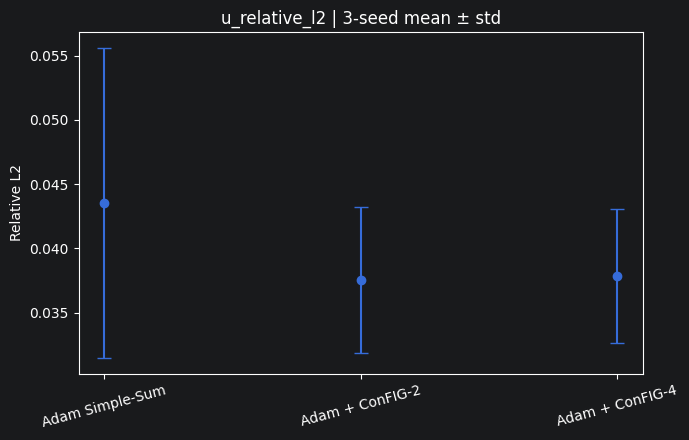

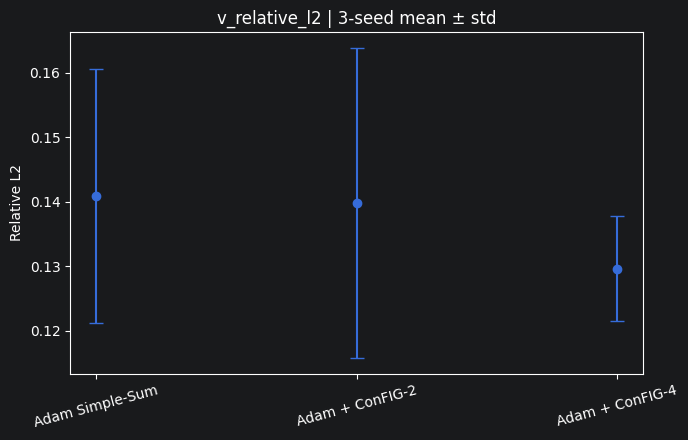

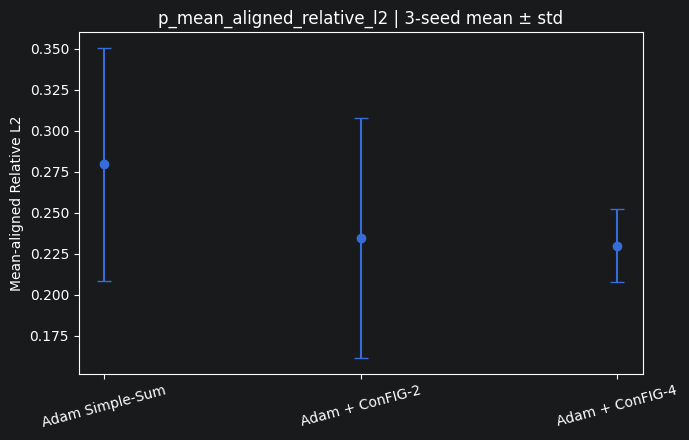

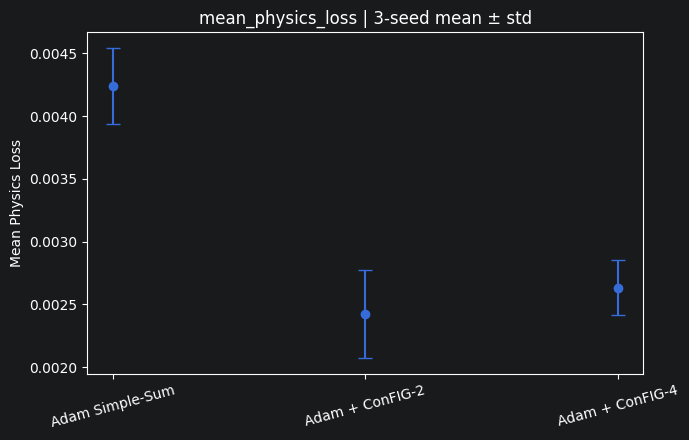

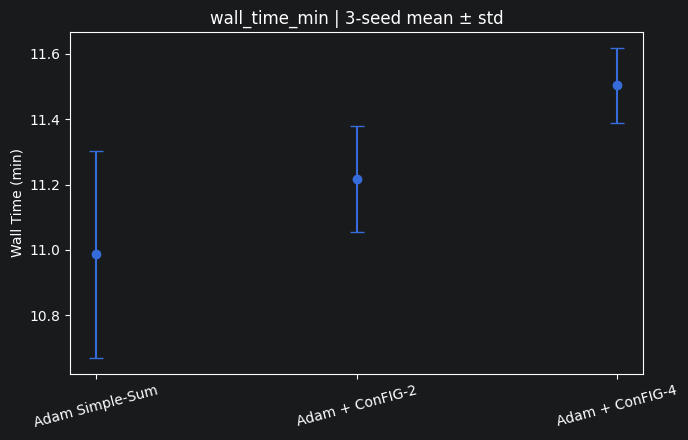

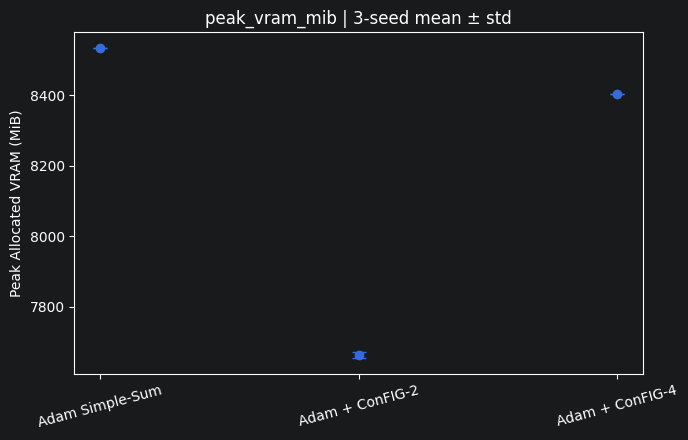

In [20]:

def comparison_metric_rows(metric):
    return [
        row for row in comparison_rows
        if row["metric"] == metric
    ]


def plot_three_method_errorbar(metric, ylabel, filename):
    rows = comparison_metric_rows(metric)
    if not rows:
        print("skip missing metric:", metric)
        return

    # 固定展示顺序。
    order = [
        "Adam Simple-Sum",
        "Adam + ConFIG-2",
        "Adam + ConFIG-4",
    ]
    rows = sorted(
        rows,
        key=lambda r: order.index(r["method"])
        if r["method"] in order else 999,
    )

    methods = [r["method"] for r in rows]
    means = [float(r["mean"]) for r in rows]
    stds = [
        0.0 if not np.isfinite(float(r["std"]))
        else float(r["std"])
        for r in rows
    ]
    x = np.arange(len(methods))

    plt.figure(figsize=(7, 4.5))
    plt.errorbar(
        x,
        means,
        yerr=stds,
        fmt="o",
        capsize=5,
    )
    plt.xticks(x, methods, rotation=15)
    plt.ylabel(ylabel)
    plt.title(f"{metric} | 3-seed mean ± std")
    plt.tight_layout()
    plt.savefig(
        AGG_DIR / filename,
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()


if comparison_rows:
    plot_three_method_errorbar(
        "u_relative_l2",
        "Relative L2",
        "compare_u_relative_l2.png",
    )
    plot_three_method_errorbar(
        "v_relative_l2",
        "Relative L2",
        "compare_v_relative_l2.png",
    )
    plot_three_method_errorbar(
        "p_mean_aligned_relative_l2",
        "Mean-aligned Relative L2",
        "compare_p_mean_aligned_relative_l2.png",
    )
    plot_three_method_errorbar(
        "mean_physics_loss",
        "Mean Physics Loss",
        "compare_mean_physics_loss.png",
    )
    plot_three_method_errorbar(
        "wall_time_min",
        "Wall Time (min)",
        "compare_wall_time.png",
    )
    plot_three_method_errorbar(
        "peak_vram_mib",
        "Peak Allocated VRAM (MiB)",
        "compare_peak_vram.png",
    )


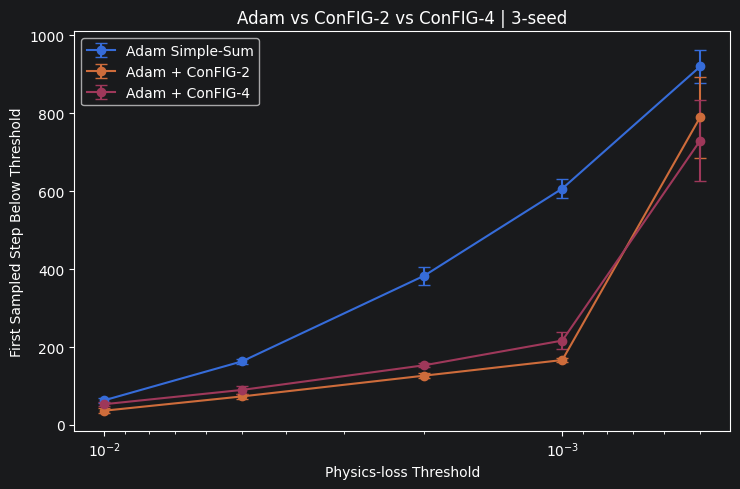

In [21]:

# 三方法 threshold crossing mean ± std。
if threshold_comparison_rows:
    methods = [
        "Adam Simple-Sum",
        "Adam + ConFIG-2",
        "Adam + ConFIG-4",
    ]

    plt.figure(figsize=(7.5, 5))
    for method in methods:
        rows = [
            row for row in threshold_comparison_rows
            if row["method"] == method
        ]
        rows = sorted(
            rows,
            key=lambda r: float(r["threshold"]),
            reverse=True,
        )
        xs = [float(r["threshold"]) for r in rows]
        ys = [float(r["mean_first_sampled_step"]) for r in rows]
        es = [
            0.0
            if not np.isfinite(float(r["std_first_sampled_step"]))
            else float(r["std_first_sampled_step"])
            for r in rows
        ]
        plt.errorbar(
            xs,
            ys,
            yerr=es,
            fmt="o-",
            capsize=4,
            label=method,
        )

    plt.xscale("log")
    plt.gca().invert_xaxis()
    plt.xlabel("Physics-loss Threshold")
    plt.ylabel("First Sampled Step Below Threshold")
    plt.title("Adam vs ConFIG-2 vs ConFIG-4 | 3-seed")
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        AGG_DIR / "compare_threshold_crossing.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()


## 20. ConFIG-4 的关键梯度诊断汇总图

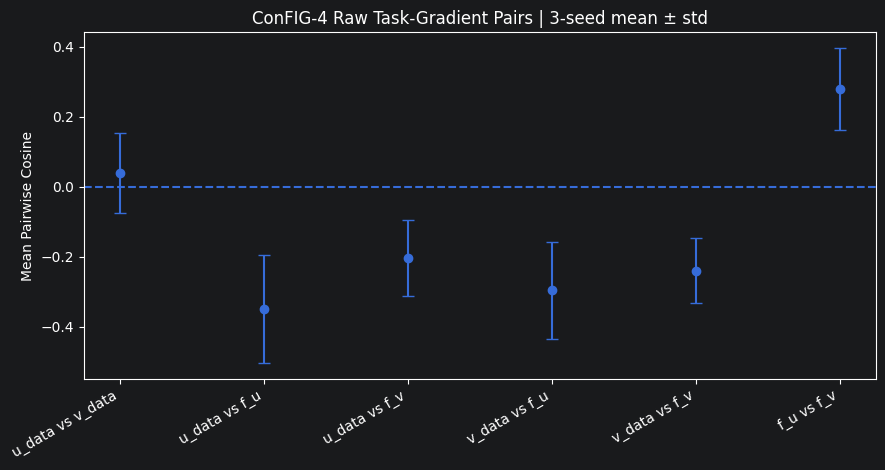

ConFIG-4 update-direction alignment summary:
metric                            | method          | n | mean     | std      
----------------------------------+-----------------+---+----------+----------
mean_min_config_alignment         | Adam + ConFIG-4 | 3 | 0.27457  | 0.0919916
late_min_config_alignment         | Adam + ConFIG-4 | 3 | 0.354535 | 0.155025 
nonpositive_config_alignment_rate | Adam + ConFIG-4 | 3 | 0        | 0        


In [22]:

# 每个 pair 的跨 seed 平均 cosine。
if pair_summary_rows:
    labels = [row["pair"] for row in pair_summary_rows]
    means = [float(row["mean_of_seed_means"]) for row in pair_summary_rows]
    stds = [
        0.0
        if not np.isfinite(float(row["std_of_seed_means"]))
        else float(row["std_of_seed_means"])
        for row in pair_summary_rows
    ]

    x = np.arange(len(labels))

    plt.figure(figsize=(9, 4.8))
    plt.errorbar(
        x,
        means,
        yerr=stds,
        fmt="o",
        capsize=4,
    )
    plt.axhline(0, linestyle="--")
    plt.xticks(x, labels, rotation=30, ha="right")
    plt.ylabel("Mean Pairwise Cosine")
    plt.title("ConFIG-4 Raw Task-Gradient Pairs | 3-seed mean ± std")
    plt.tight_layout()
    plt.savefig(
        AGG_DIR / "config4_pairwise_cosine_mean_std.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()


# ConFIG 公共方向 alignment 的核心统计。
alignment_metrics = [
    "mean_min_config_alignment",
    "late_min_config_alignment",
    "nonpositive_config_alignment_rate",
]

alignment_rows = [
    row for row in summary4_rows
    if row["metric"] in alignment_metrics
]

print("ConFIG-4 update-direction alignment summary:")
print_table(
    alignment_rows,
    columns=["metric", "method", "n", "mean", "std"],
)



## 21. 结果解释边界

本 notebook 跑完后，重点回答四个问题：

1. **ConFIG-4 相比 ConFIG-2 是否改善最终场精度？**

   重点看：
   - $u$ Relative L2；
   - $v$ Relative L2；
   - pressure mean-aligned Relative L2。

2. **细粒度协调是否进一步改善 physics optimization？**

   重点看：
   - mean / final $L_{\mathrm{physics}}$；
   - physics threshold crossing。

3. **2-loss aggregation 到底隐藏了什么？**

   重点看六个原始 pair：
   - `u_data vs v_data`
   - `u_data vs f_u`
   - `u_data vs f_v`
   - `v_data vs f_u`
   - `v_data vs f_v`
   - `f_u vs f_v`

4. **收益是否值得额外计算成本？**

   ConFIG-2 每个 optimizer step 需要 2 个高层 loss-specific parameter-gradient extractions；ConFIG-4 需要 4 个。必须结合真实 wall time，而不是只根据梯度数量推断运行时间。

### 关于 ConFIG 机制验证

Raw pairwise cosine 为负，并不意味着 ConFIG 失败。真正更直接的机制指标是：

$$
\cos(g_{\mathrm{ConFIG4}},g_i),
\qquad i\in
\{u,v,f_u,f_v\}.
$$

尤其关注：

$$
\min_i\cos(g_{\mathrm{ConFIG4}},g_i).
$$

如果这个量在绝大多数训练 step 中保持正值，说明最终公共更新方向对四个原始 task gradients 均具有正向 alignment。它比单纯观察 raw task gradients 是否互相冲突更接近 ConFIG 的直接作用对象。

### 关于显存

Adam baseline 与 ConFIG-2 的历史 profiling 代码路径并非完全等价，因此即使已有表中 Adam 的 peak VRAM 更高，也不能把差值解释成“ConFIG 降低显存”。本次 ConFIG-4 的 VRAM 主要用于观察随 task 数量增加后当前实现的真实资源变化，并为后续 M-ConFIG 建立资源基线。


## 22. 下一阶段决策规则


跑完 3 seeds 后，不需要要求 ConFIG-4 在所有指标上都胜过 ConFIG-2。

更重要的是根据结果进入以下分支：

```text
ConFIG-4 明显优于 ConFIG-2
        ↓
说明细粒度梯度冲突值得单独协调
        ↓
进入 4-loss M-ConFIG fixed round-robin
        ↓
研究 staleness / cost

ConFIG-4 ≈ ConFIG-2，但明显更贵
        ↓
说明 2-loss aggregation 可能已经足够
        ↓
4-loss 主要作为冲突诊断与 M-ConFIG 压力测试
        ↓
后续讨论“哪些梯度值得刷新”

ConFIG-4 比 ConFIG-2 更差
        ↓
分析六个 pair + post-ConFIG alignment
        ↓
检查是否存在过度细分、噪声目标、投影折中问题
        ↓
再决定是否补 3-loss 消融
```

因此 **3-loss 暂时不跑**。只有当 4-loss 结果需要解释“问题来自 data 拆分还是 physics 拆分”时，再用：

$$
\{L_u,L_v,L_{\mathrm{physics}}\}
$$

或

$$
\{L_{\mathrm{data}},L_{f_u},L_{f_v}\}
$$

做解释性消融。


## 23. 输出文件清单

In [23]:

print("4-loss outputs root:")
print(FOURLOSS_ROOT.resolve())

print(
    """
Expected structure:

navier_stokes_4loss_multiseed/
├── seed_0/
│   ├── config_4loss/
│   │   ├── model.pt
│   │   ├── history.npz
│   │   ├── predictions.npz
│   │   ├── field_metrics.csv
│   │   ├── history_summary.csv
│   │   ├── gradient_diagnostics.csv
│   │   ├── threshold_steps.csv
│   │   └── run_meta.json
│   └── figures/
├── seed_1/
├── seed_2/
└── aggregate/
    ├── all_field_metrics_config4.csv
    ├── all_history_metrics_config4.csv
    ├── all_threshold_steps_config4.csv
    ├── mean_std_summary_config4.csv
    ├── pairwise_cosine_mean_std.csv
    ├── threshold_mean_std_config4.csv
    ├── comparison_adam_config2_config4.csv
    ├── threshold_comparison_adam_config2_config4.csv
    └── *.png
"""
)


4-loss outputs root:
/home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/navier_stokes_4loss_multiseed

Expected structure:

navier_stokes_4loss_multiseed/
├── seed_0/
│   ├── config_4loss/
│   │   ├── model.pt
│   │   ├── history.npz
│   │   ├── predictions.npz
│   │   ├── field_metrics.csv
│   │   ├── history_summary.csv
│   │   ├── gradient_diagnostics.csv
│   │   ├── threshold_steps.csv
│   │   └── run_meta.json
│   └── figures/
├── seed_1/
├── seed_2/
└── aggregate/
    ├── all_field_metrics_config4.csv
    ├── all_history_metrics_config4.csv
    ├── all_threshold_steps_config4.csv
    ├── mean_std_summary_config4.csv
    ├── pairwise_cosine_mean_std.csv
    ├── threshold_mean_std_config4.csv
    ├── comparison_adam_config2_config4.csv
    ├── threshold_comparison_adam_config2_config4.csv
    └── *.png

